In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import glob
from pathlib import Path

import numpy as np
import pandas as pd

from aicsimageio import AICSImage, readers

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

import matplotlib.font_manager as font_manager

In [2]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['svg.fonttype'] = 'none'

## load layout files for multiple experiments

In [3]:
Experiment1Layout = pd.read_csv("250128_ARMC5mAC_TotalPolII/METADATA/250128_ARMC5mAC_TotalPolII.csv")
Experiment2Layout = pd.read_csv("250203_ARMC5mAC_TotalPolII/METADATA/250203_ARMC5mAC_TotalPolII.csv")
Experiment3Layout = pd.read_csv("250210_ARMC5mAC_PhosphoPolII/METADATA/250210_ARMC5mAC_PhosphoPolII.csv")
Experiment4Layout = pd.read_csv("250505_ARMC5mAC_PhosphoPolII/METADATA/250505_ARMC5mAC_PhosphoPolII.csv")
Experiment5Layout = pd.read_csv("260119_ARMC5mAC_TotalPhospho/METADATA/260119_ARMC5mAC_TotalPhospho.csv")
Experiment6Layout = pd.read_csv("260127_ARMC5mAC_PhosphoEU/METADATA/260127_ARMC5mAC_PhosphoEU.csv")

## load quantification files and assemble into dataframes

In [4]:
dir_path = "/Users/alexandergillis/Desktop/KATANA_PULL/"

Experiment1_Quantification_Directory_Cycle1 = Path(dir_path + "250128_ARMC5mAC_TotalPolII/20250203_154917_500/QUANTIFICATION/")
Experiment1_Quantification_Directory_Cycle2 = Path(dir_path + "250128_ARMC5mAC_TotalPolII/20250206_212015_735/QUANTIFICATION/")

Experiment2_Quantification_Directory_Cycle1 = Path(dir_path + "250203_ARMC5mAC_TotalPolII/20250207_215215_806/QUANTIFICATION/")
Experiment2_Quantification_Directory_Cycle2 = Path(dir_path + "250203_ARMC5mAC_TotalPolII/20250210_170713_881/QUANTIFICATION/")

Experiment3_Quantification_Directory_Cycle1 = Path(dir_path + "250210_ARMC5mAC_PhosphoPolII/20250218_143200_062/QUANTIFICATION/")

Experiment4_Quantification_Directory_Cycle1 = Path(dir_path + "250505_ARMC5mAC_PhosphoPolII/20250509_142955_544/QUANTIFICATION/")

Experiment5_Quantification_Directory_Cycle1 = Path(dir_path + "260119_ARMC5mAC_TotalPhospho/20260123_205850_903/QUANTIFICATION/")

Experiment6_Quantification_Directory_Cycle1 = Path(dir_path + "260127_ARMC5mAC_PhosphoEU/20260202_172318_376/QUANTIFICATION/")
Experiment6_Quantification_Directory_Cycle2 = Path(dir_path + "260127_ARMC5mAC_PhosphoEU/20260203_171323_021/QUANTIFICATION/")

Experiment1_Cycle1_Quantification_Files = glob.glob(str(Experiment1_Quantification_Directory_Cycle1 / "*.csv"))
Experiment1_Cycle2_Quantification_Files = glob.glob(str(Experiment1_Quantification_Directory_Cycle2 / "*.csv"))

Experiment2_Cycle1_Quantification_Files = glob.glob(str(Experiment2_Quantification_Directory_Cycle1 / "*.csv"))
Experiment2_Cycle2_Quantification_Files = glob.glob(str(Experiment2_Quantification_Directory_Cycle2 / "*.csv"))

Experiment3_Cycle1_Quantification_Files = glob.glob(str(Experiment3_Quantification_Directory_Cycle1 / "*.csv"))
Experiment4_Cycle1_Quantification_Files = glob.glob(str(Experiment4_Quantification_Directory_Cycle1 / "*.csv"))
Experiment5_Cycle1_Quantification_Files = glob.glob(str(Experiment5_Quantification_Directory_Cycle1 / "*.csv"))

Experiment6_Cycle1_Quantification_Files = glob.glob(str(Experiment6_Quantification_Directory_Cycle1 / "*.csv"))
Experiment6_Cycle2_Quantification_Files = glob.glob(str(Experiment6_Quantification_Directory_Cycle2 / "*.csv"))



[len(i) for i in [Experiment1_Cycle1_Quantification_Files, 
                  Experiment1_Cycle2_Quantification_Files, 
                  Experiment2_Cycle1_Quantification_Files, 
                  Experiment2_Cycle2_Quantification_Files, 
                  Experiment3_Cycle1_Quantification_Files, 
                  Experiment4_Cycle1_Quantification_Files, 
                  Experiment5_Cycle1_Quantification_Files,
                  Experiment6_Cycle1_Quantification_Files, 
                  Experiment6_Cycle2_Quantification_Files, 
                  ]]

[960, 939, 960, 927, 915, 960, 960, 960, 2160]

### experiment 1

In [5]:
qdfs = list()


for f in tqdm(Experiment1_Cycle1_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment1_Cycle1_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment1_Cycle1_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment1_Cycle1_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment1_Cycle1_PerCell['fov'] = fovs

Intensities_Experiment1_Cycle1 = pd.DataFrame({
    "WELL" : Experiment1_Cycle1_PerCell['well'],
    "IF_561_Intensity" : Experiment1_Cycle1_PerCell['Nuclei_intensity_mean_561'],
    "GFP_Intensity" : Experiment1_Cycle1_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment1_Cycle1_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment1_Cycle1_PerCell['Nuclei_area']
})

100%|████████████████████████████████████████| 960/960 [00:04<00:00, 221.87it/s]


In [6]:
qdfs = list()


for f in tqdm(Experiment1_Cycle2_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment1_Cycle2_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment1_Cycle2_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment1_Cycle2_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment1_Cycle2_PerCell['fov'] = fovs

Intensities_Experiment1_Cycle2 = pd.DataFrame({
    "WELL" : Experiment1_Cycle2_PerCell['well'],
    "Alexa647_Intensity" : Experiment1_Cycle2_PerCell['Nuclei_intensity_mean_647'],
    "NucleusArea2" : Experiment1_Cycle2_PerCell['Nuclei_area']
})

100%|████████████████████████████████████████| 939/939 [00:03<00:00, 281.49it/s]


### experiment 2

In [7]:
qdfs = list()


for f in tqdm(Experiment2_Cycle1_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment2_Cycle1_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment2_Cycle1_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment2_Cycle1_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment2_Cycle1_PerCell['fov'] = fovs

100%|████████████████████████████████████████| 960/960 [00:03<00:00, 268.25it/s]


In [8]:
Intensities_Experiment2_Cycle1 = pd.DataFrame({
    "WELL" : Experiment2_Cycle1_PerCell['well'],
    "IF_561_Intensity" : Experiment2_Cycle1_PerCell['Nuclei_intensity_mean_561'],
    "GFP_Intensity" : Experiment2_Cycle1_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment2_Cycle1_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment2_Cycle1_PerCell['Nuclei_area']
})

In [9]:
qdfs = list()


for f in tqdm(Experiment2_Cycle2_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment2_Cycle2_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment2_Cycle2_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment2_Cycle2_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment2_Cycle2_PerCell['fov'] = fovs

Intensities_Experiment2_Cycle2 = pd.DataFrame({
    "WELL" : Experiment2_Cycle2_PerCell['well'],
    "Alexa647_Intensity" : Experiment2_Cycle2_PerCell['Nuclei_intensity_mean_647'],
    "NucleusArea2" : Experiment2_Cycle2_PerCell['Nuclei_area']
})

100%|████████████████████████████████████████| 927/927 [00:03<00:00, 308.55it/s]


### experiment 3

In [10]:
qdfs = list()


for f in tqdm(Experiment3_Cycle1_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment3_Cycle1_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment3_Cycle1_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment3_Cycle1_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment3_Cycle1_PerCell['fov'] = fovs

100%|████████████████████████████████████████| 915/915 [00:03<00:00, 288.66it/s]


In [11]:
Intensities_Experiment3_Cycle1 = pd.DataFrame({
    "WELL" : Experiment3_Cycle1_PerCell['well'],
    "Alexa647_Intensity" : Experiment3_Cycle1_PerCell['Nuclei_intensity_mean_647'],
    "GFP_Intensity" : Experiment3_Cycle1_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment3_Cycle1_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment3_Cycle1_PerCell['Nuclei_area']
})

### experiment 4

In [12]:
qdfs = list()

for f in tqdm(Experiment4_Cycle1_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment4_Cycle1_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment4_Cycle1_PerCell['file'].tolist()

wellnames = [f[4:7] for f in files]
Experiment4_Cycle1_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment4_Cycle1_PerCell['fov'] = fovs

Intensities_Experiment4_Cycle1 = pd.DataFrame({
    "WELL" : Experiment4_Cycle1_PerCell['well'],
    "Alexa647_Intensity" : Experiment4_Cycle1_PerCell['Nuclei_intensity_mean_647'],
    "GFP_Intensity" : Experiment4_Cycle1_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment4_Cycle1_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment4_Cycle1_PerCell['Nuclei_area']
})

100%|█████████████████████████████████████████| 960/960 [00:17<00:00, 54.32it/s]


### experiment 5

In [13]:
qdfs = list()

for f in tqdm(Experiment5_Cycle1_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment5_Cycle1_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment5_Cycle1_PerCell['file'].tolist()

wellnames = [f[4:7] for f in files]
Experiment5_Cycle1_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment5_Cycle1_PerCell['fov'] = fovs

Intensities_Experiment5_Cycle1 = pd.DataFrame({
    "WELL" : Experiment5_Cycle1_PerCell['well'],
    "Alexa647_Intensity" : Experiment5_Cycle1_PerCell['Nuclei_intensity_mean_640'],
    "GFP_Intensity" : Experiment5_Cycle1_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment5_Cycle1_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment5_Cycle1_PerCell['Nuclei_area']
})

100%|████████████████████████████████████████| 960/960 [00:04<00:00, 207.19it/s]


### experiment 6

In [14]:
qdfs = list()

for f in tqdm(Experiment6_Cycle1_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment6_Cycle1_PerCell = pd.concat(qdfs, ignore_index=True)
files = Experiment6_Cycle1_PerCell['file'].tolist()

wellnames = [f[4:7] for f in files]
Experiment6_Cycle1_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment6_Cycle1_PerCell['fov'] = fovs

100%|████████████████████████████████████████| 960/960 [00:03<00:00, 308.47it/s]


In [15]:
Intensities_Experiment6_Cycle1 = pd.DataFrame({
    "WELL" : Experiment6_Cycle1_PerCell['well'],
    "IF_561_Intensity" : Experiment6_Cycle1_PerCell['Nuclei_intensity_mean_561'],
    "GFP_Intensity" : Experiment6_Cycle1_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment6_Cycle1_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment6_Cycle1_PerCell['Nuclei_area']
})

In [16]:
qdfs = list()

for f in tqdm(Experiment6_Cycle2_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment6_Cycle2_PerCell = pd.concat(qdfs, ignore_index=True)
files = Experiment6_Cycle2_PerCell['file'].tolist()
wellnames = [f[4:7] for f in files]
Experiment6_Cycle2_PerCell['well'] = wellnames
fovs = [f[39:43] for f in files]
Experiment6_Cycle2_PerCell['fov'] = fovs
Intensities_Experiment6_Cycle2 = pd.DataFrame({
    "WELL" : Experiment6_Cycle2_PerCell['well'],
    "Alexa647_Intensity" : Experiment6_Cycle2_PerCell['Nuclei_intensity_mean_647'],
    "DAPI_Intensity" : Experiment6_Cycle2_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea2" : Experiment6_Cycle2_PerCell['Nuclei_area']
})

100%|██████████████████████████████████████| 2160/2160 [00:06<00:00, 359.68it/s]


## average by individual wells, add cell counts, and merge with layouts,

In [17]:
CountsByWell1 = Intensities_Experiment1_Cycle1.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell1.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment1_Cycle1 = Intensities_Experiment1_Cycle1.groupby('WELL').mean().reset_index().merge(Experiment1Layout, how = 'left')
IntensitiesByWell_Experiment1_Cycle1 = IntensitiesByWell_Experiment1_Cycle1.merge(CountsByWell1)
IntensitiesByWell_Experiment1_Cycle2 = Intensities_Experiment1_Cycle2.groupby('WELL').mean().reset_index()

IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1_Cycle1.merge(IntensitiesByWell_Experiment1_Cycle2, how = 'left', left_on = "WELL", right_on = "WELL")
IntensitiesByWell_Experiment1['EXPERIMENT'] = '250128_ARMC5mAC_TotalPolII'

In [18]:
CountsByWell2 = Intensities_Experiment2_Cycle1.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell2.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment2_Cycle1 = Intensities_Experiment2_Cycle1.groupby('WELL').mean().reset_index().merge(Experiment2Layout, how = 'left')
IntensitiesByWell_Experiment2_Cycle1 = IntensitiesByWell_Experiment2_Cycle1.merge(CountsByWell1)
IntensitiesByWell_Experiment2_Cycle2 = Intensities_Experiment2_Cycle2.groupby('WELL').mean().reset_index()

IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2_Cycle1.merge(IntensitiesByWell_Experiment2_Cycle2, how = 'left', left_on = "WELL", right_on = "WELL")
IntensitiesByWell_Experiment2['EXPERIMENT'] = '250203_ARMC5mAC_TotalPolII'

In [19]:
CountsByWell3 = Intensities_Experiment3_Cycle1.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell3.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment3_Cycle1 = Intensities_Experiment3_Cycle1.groupby('WELL').mean().reset_index().merge(Experiment3Layout, how = 'left')
IntensitiesByWell_Experiment3_Cycle1 = IntensitiesByWell_Experiment3_Cycle1.merge(CountsByWell3)

IntensitiesByWell_Experiment3 = IntensitiesByWell_Experiment3_Cycle1
IntensitiesByWell_Experiment3['EXPERIMENT'] = '250210_ARMC5mAC_PhosphoPolII'

In [20]:
CountsByWell4 = Intensities_Experiment4_Cycle1.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell4.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment4_Cycle1 = Intensities_Experiment4_Cycle1.groupby('WELL').mean().reset_index().merge(Experiment4Layout, how = 'left')
IntensitiesByWell_Experiment4_Cycle1 = IntensitiesByWell_Experiment4_Cycle1.merge(CountsByWell4)

IntensitiesByWell_Experiment4 = IntensitiesByWell_Experiment4_Cycle1
IntensitiesByWell_Experiment4['EXPERIMENT'] = '250505_ARMC5mAC_PhosphoPolII'

In [21]:
CountsByWell5 = Intensities_Experiment5_Cycle1.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell5.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment5_Cycle1 = Intensities_Experiment5_Cycle1.groupby('WELL').mean().reset_index().merge(Experiment5Layout, how = 'left')
IntensitiesByWell_Experiment5_Cycle1 = IntensitiesByWell_Experiment5_Cycle1.merge(CountsByWell5)
IntensitiesByWell_Experiment5 = IntensitiesByWell_Experiment5_Cycle1
IntensitiesByWell_Experiment5['EXPERIMENT'] = '260119_ARMC5mAC_TotalPhospho'

In [22]:
CountsByWell6 = Intensities_Experiment6_Cycle1.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell6.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment6_Cycle1 = Intensities_Experiment6_Cycle1.groupby('WELL').mean().reset_index().merge(Experiment6Layout, how = 'left')
IntensitiesByWell_Experiment6_Cycle1 = IntensitiesByWell_Experiment6_Cycle1.merge(CountsByWell6)
IntensitiesByWell_Experiment6_Cycle2 = Intensities_Experiment6_Cycle2.groupby('WELL').mean().reset_index()

IntensitiesByWell_Experiment6 = IntensitiesByWell_Experiment6_Cycle1.merge(IntensitiesByWell_Experiment6_Cycle2, how = 'left', left_on = "WELL", right_on = "WELL")
IntensitiesByWell_Experiment6['EXPERIMENT'] = '260127_ARMC5mAC_PhosphoEU'

## save well means to csv

In [23]:
IntensitiesByWell_Experiment1.to_csv('250128_ARMC5mAC_TotalPolII/250128_ARMC5mAC_TotalPolII_well_means.csv')
IntensitiesByWell_Experiment2.to_csv('250203_ARMC5mAC_TotalPolII/250203_ARMC5mAC_TotalPolII_well_means.csv')
IntensitiesByWell_Experiment3.to_csv('250210_ARMC5mAC_PhosphoPolII/250210_ARMC5mAC_PhosphoPolII_well_means.csv')
IntensitiesByWell_Experiment4.to_csv('250505_ARMC5mAC_PhosphoPolII/250505_ARMC5mAC_PhosphoPolII_well_means.csv')
IntensitiesByWell_Experiment5.to_csv('260119_ARMC5mAC_TotalPhospho/260119_ARMC5mAC_TotalPhospho_well_means.csv')
IntensitiesByWell_Experiment6.to_csv('260127_ARMC5mAC_PhosphoEU/260127_ARMC5mAC_PhosphoEU_well_means.csv')

## examine raw data per experiment

In [24]:
IntensitiesByWell_Experiment1.CELL.unique()

array(['HCT116 OsTIRF74G', 'HCT116 OsTIRF74G ARMC5mAC Clone 5A1',
       'HCT116 OsTIRF74G ARMC5mAC Clone 5F9'], dtype=object)

In [25]:
IntensitiesByWell_Experiment1.DRUG.unique()

array(['No addition', 'Vehicle', '10 µM 5PhIAA'], dtype=object)

In [26]:
cell_relabel = dict(zip(['HCT116 OsTIRF74G', 'HCT116 OsTIRF74G ARMC5mAC Clone 5A1', 'HCT116 OsTIRF74G ARMC5mAC Clone 5F9'],
                        ['OsTIRF74G', 'ARMC5mAC 5A1', 'ARMC5mAC Clone 5F9']))

In [27]:
cell_relabel_order = ['OsTIRF74G', 'ARMC5mAC 5A1', 'ARMC5mAC Clone 5F9']

### experiment 1

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/3280853971.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment1_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment1_Baseline['CELL'].map(cell_relabel)


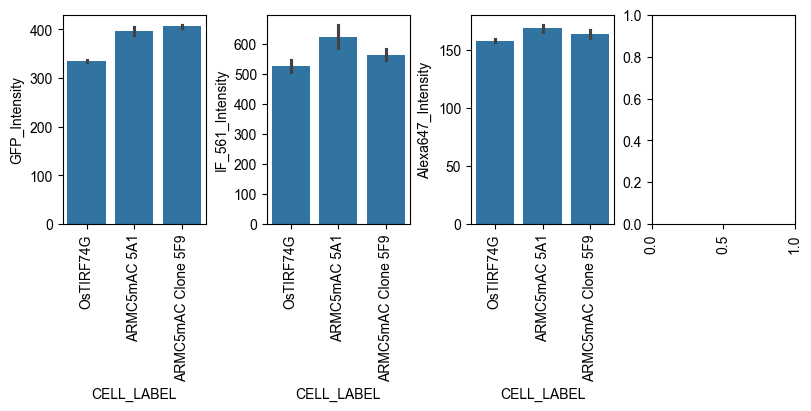

In [28]:
f, a = plt.subplots(ncols = 4, figsize = (8,4), layout = 'constrained')

IntensitiesByWell_Experiment1_Baseline = IntensitiesByWell_Experiment1.query('DRUG == "No addition" | DRUG == "Vehicle"')
IntensitiesByWell_Experiment1_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment1_Baseline['CELL'].map(cell_relabel)

sns.barplot(IntensitiesByWell_Experiment1_Baseline,
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'GFP_Intensity',
            ax = a[0])

sns.barplot(IntensitiesByWell_Experiment1_Baseline.query('PRIMARY == "Total Pol II F12"'),
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'IF_561_Intensity',
            ax = a[1])

sns.barplot(IntensitiesByWell_Experiment1_Baseline.query('EU == "EU 1 mM, 30 mins"'),
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'Alexa647_Intensity',
            ax = a[2])

for i in range(4):
    a[i].tick_params(axis = 'x', labelrotation = 90)

In [29]:
IntensitiesByWell_Experiment1_Baseline.PRIMARY.unique(), IntensitiesByWell_Experiment1_Baseline.EU.unique()

(array(['Total Pol II F12', 'No primary'], dtype=object),
 array(['No addition', 'EU 1 mM, 30 mins'], dtype=object))

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/4216093308.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment1_Exclude_No_Addition['TIME_MINUTES'] = IntensitiesByWell_Experiment1_Exclude_No_Addition['DRUG TIME HOURS'].astype('int')
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/4216093308.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment1_Exclude_No_Addition['CELL_LABEL'] = IntensitiesByWell_Experiment1_Exclude_N

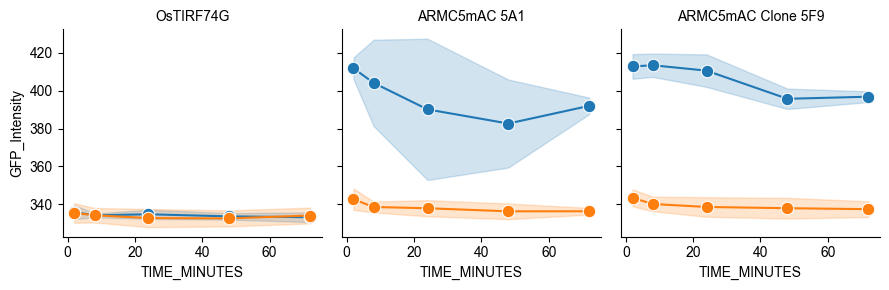

In [30]:
IntensitiesByWell_Experiment1_Exclude_No_Addition = IntensitiesByWell_Experiment1.query('DRUG != "No addition"')
IntensitiesByWell_Experiment1_Exclude_No_Addition['TIME_MINUTES'] = IntensitiesByWell_Experiment1_Exclude_No_Addition['DRUG TIME HOURS'].astype('int')


IntensitiesByWell_Experiment1_Exclude_No_Addition['CELL_LABEL'] = IntensitiesByWell_Experiment1_Exclude_No_Addition['CELL'].map(cell_relabel)

g = sns.FacetGrid(IntensitiesByWell_Experiment1_Exclude_No_Addition,
                  col = 'CELL_LABEL',
                  col_order =  cell_relabel_order)

g.map_dataframe(sns.lineplot,
                x = 'TIME_MINUTES',
                y = 'GFP_Intensity',
                hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
                marker = 'o', markersize = 9,
                errorbar = 'sd')

g.set_titles(template="{col_name}")

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/1984614007.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment1_F12['TIME_MINUTES'] = IntensitiesByWell_Experiment1_F12['DRUG TIME HOURS'].astype('int')
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/1984614007.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment1_F12['CELL_LABEL'] = IntensitiesByWell_Experiment1_F12['CELL'].map(cell_relabel)


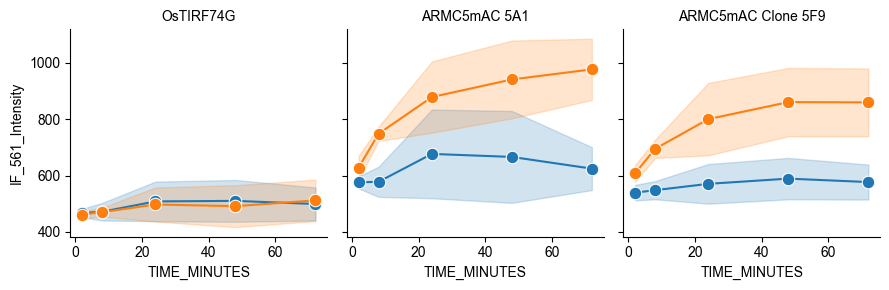

In [31]:
IntensitiesByWell_Experiment1_F12 = IntensitiesByWell_Experiment1.query('PRIMARY == "Total Pol II F12" & DRUG != "No addition"')
IntensitiesByWell_Experiment1_F12['TIME_MINUTES'] = IntensitiesByWell_Experiment1_F12['DRUG TIME HOURS'].astype('int')


IntensitiesByWell_Experiment1_F12['CELL_LABEL'] = IntensitiesByWell_Experiment1_F12['CELL'].map(cell_relabel)

g = sns.FacetGrid(IntensitiesByWell_Experiment1_F12,
                  col = 'CELL_LABEL',
                  col_order =  cell_relabel_order)

g.map_dataframe(sns.lineplot,
                x = 'TIME_MINUTES',
                y = 'IF_561_Intensity',
                hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
                marker = 'o', markersize = 9,
                errorbar = 'sd')

g.set_titles(template="{col_name}")

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/2043140342.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment1_EU['TIME_MINUTES'] = IntensitiesByWell_Experiment1_EU['DRUG TIME HOURS'].astype('int')
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/2043140342.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment1_EU['CELL_LABEL'] = IntensitiesByWell_Experiment1_EU['CELL'].map(cell_relabel)


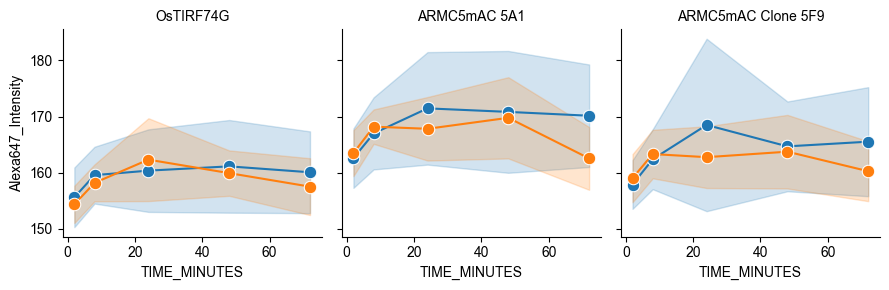

In [32]:
IntensitiesByWell_Experiment1_EU = IntensitiesByWell_Experiment1.query('EU == "EU 1 mM, 30 mins" & DRUG != "No addition"')
IntensitiesByWell_Experiment1_EU['TIME_MINUTES'] = IntensitiesByWell_Experiment1_EU['DRUG TIME HOURS'].astype('int')


IntensitiesByWell_Experiment1_EU['CELL_LABEL'] = IntensitiesByWell_Experiment1_EU['CELL'].map(cell_relabel)

g = sns.FacetGrid(IntensitiesByWell_Experiment1_EU,
                  col = 'CELL_LABEL',
                  col_order =  cell_relabel_order)

g.map_dataframe(sns.lineplot,
                x = 'TIME_MINUTES',
                y = 'Alexa647_Intensity',
                hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
                marker = 'o', markersize = 9,
                errorbar = 'sd')

g.set_titles(template="{col_name}")

### experiment 2

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/1813116177.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment2_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment2_Baseline['CELL'].map(cell_relabel)


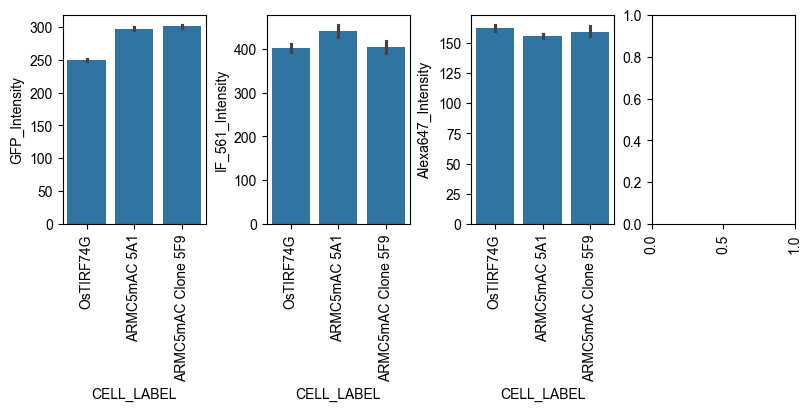

In [33]:
f, a = plt.subplots(ncols = 4, figsize = (8,4), layout = 'constrained')

IntensitiesByWell_Experiment2_Baseline = IntensitiesByWell_Experiment2.query('DRUG == "No addition" | DRUG == "Vehicle"')
IntensitiesByWell_Experiment2_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment2_Baseline['CELL'].map(cell_relabel)

sns.barplot(IntensitiesByWell_Experiment2_Baseline,
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'GFP_Intensity',
            ax = a[0])

sns.barplot(IntensitiesByWell_Experiment2_Baseline.query('PRIMARY == "Total Pol II F12"'),
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'IF_561_Intensity',
            ax = a[1])

sns.barplot(IntensitiesByWell_Experiment2_Baseline.query('EU == "EU 1 mM, 30 mins"'),
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'Alexa647_Intensity',
            ax = a[2])

for i in range(4):
    a[i].tick_params(axis = 'x', labelrotation = 90)

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/3288702133.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment2_Exclude_No_Addition['TIME_MINUTES'] = IntensitiesByWell_Experiment2_Exclude_No_Addition['DRUG TIME HOURS'].astype('int')
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/3288702133.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment2_Exclude_No_Addition['CELL_LABEL'] = IntensitiesByWell_Experiment2_Exclude_N

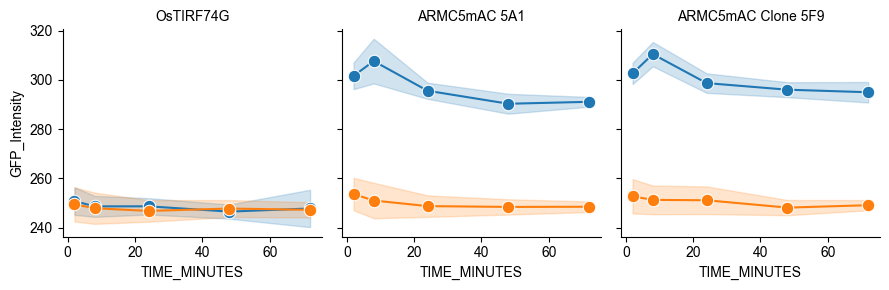

In [34]:
IntensitiesByWell_Experiment2_Exclude_No_Addition = IntensitiesByWell_Experiment2.query('DRUG != "No addition"')
IntensitiesByWell_Experiment2_Exclude_No_Addition['TIME_MINUTES'] = IntensitiesByWell_Experiment2_Exclude_No_Addition['DRUG TIME HOURS'].astype('int')


IntensitiesByWell_Experiment2_Exclude_No_Addition['CELL_LABEL'] = IntensitiesByWell_Experiment2_Exclude_No_Addition['CELL'].map(cell_relabel)

g = sns.FacetGrid(IntensitiesByWell_Experiment2_Exclude_No_Addition,
                  col = 'CELL_LABEL',
                  col_order =  cell_relabel_order)

g.map_dataframe(sns.lineplot,
                x = 'TIME_MINUTES',
                y = 'GFP_Intensity',
                hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
                marker = 'o', markersize = 9,
                errorbar = 'sd')

g.set_titles(template="{col_name}")

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/310271368.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment2_F12['TIME_MINUTES'] = IntensitiesByWell_Experiment2_F12['DRUG TIME HOURS'].astype('int')
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/310271368.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment2_F12['CELL_LABEL'] = IntensitiesByWell_Experiment2_F12['CELL'].map(cell_relabel)


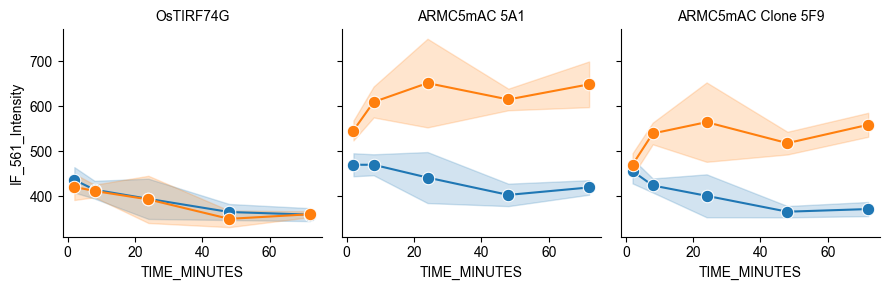

In [35]:
IntensitiesByWell_Experiment2_F12 = IntensitiesByWell_Experiment2.query('PRIMARY == "Total Pol II F12" & DRUG != "No addition"')
IntensitiesByWell_Experiment2_F12['TIME_MINUTES'] = IntensitiesByWell_Experiment2_F12['DRUG TIME HOURS'].astype('int')


IntensitiesByWell_Experiment2_F12['CELL_LABEL'] = IntensitiesByWell_Experiment2_F12['CELL'].map(cell_relabel)

g = sns.FacetGrid(IntensitiesByWell_Experiment2_F12,
                  col = 'CELL_LABEL',
                  col_order =  cell_relabel_order)

g.map_dataframe(sns.lineplot,
                x = 'TIME_MINUTES',
                y = 'IF_561_Intensity',
                hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
                marker = 'o', markersize = 9,
                errorbar = 'sd')

g.set_titles(template="{col_name}")

### experiment 3

In [36]:
IntensitiesByWell_Experiment3.PRIMARY.unique()

array(['pSer2 Pol II 3E10', 'pSer5 Pol II 3E8', 'No primary'],
      dtype=object)

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/877051357.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment3_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment3_Baseline['CELL'].map(cell_relabel)


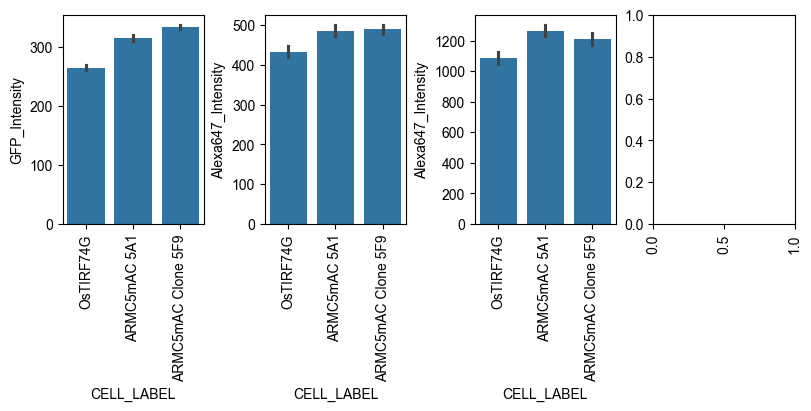

In [37]:
f, a = plt.subplots(ncols = 4, figsize = (8,4), layout = 'constrained')

IntensitiesByWell_Experiment3_Baseline = IntensitiesByWell_Experiment3.query('DRUG == "No addition" | DRUG == "Vehicle"')
IntensitiesByWell_Experiment3_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment3_Baseline['CELL'].map(cell_relabel)

sns.barplot(IntensitiesByWell_Experiment3_Baseline,
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'GFP_Intensity',
            ax = a[0])

sns.barplot(IntensitiesByWell_Experiment3_Baseline.query('PRIMARY == "pSer2 Pol II 3E10"'),
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'Alexa647_Intensity',
            ax = a[1])

sns.barplot(IntensitiesByWell_Experiment3_Baseline.query('PRIMARY == "pSer5 Pol II 3E8"'),
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'Alexa647_Intensity',
            ax = a[2])

for i in range(4):
    a[i].tick_params(axis = 'x', labelrotation = 90)

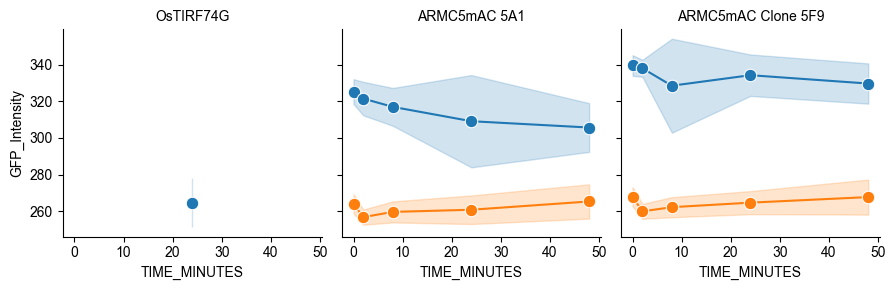

In [38]:
IntensitiesByWell_Experiment3_Exclude_No_Addition = IntensitiesByWell_Experiment3.query('DRUG != "No addition"')
IntensitiesByWell_Experiment3_Exclude_No_Addition['TIME_MINUTES'] = IntensitiesByWell_Experiment3_Exclude_No_Addition['DRUG TIME HOURS'].astype('int')


IntensitiesByWell_Experiment3_Exclude_No_Addition['CELL_LABEL'] = IntensitiesByWell_Experiment3_Exclude_No_Addition['CELL'].map(cell_relabel)

g = sns.FacetGrid(IntensitiesByWell_Experiment3_Exclude_No_Addition,
                  col = 'CELL_LABEL',
                  col_order =  cell_relabel_order)

g.map_dataframe(sns.lineplot,
                x = 'TIME_MINUTES',
                y = 'GFP_Intensity',
                hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
                marker = 'o', markersize = 9,
                errorbar = 'sd')

g.set_titles(template="{col_name}")

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/3647192574.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment3_3E10['TIME_MINUTES'] = IntensitiesByWell_Experiment3_3E10['DRUG TIME HOURS'].astype('int')
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/3647192574.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment3_3E10['CELL_LABEL'] = IntensitiesByWell_Experiment3_3E10['CELL'].map(cell_relabel)


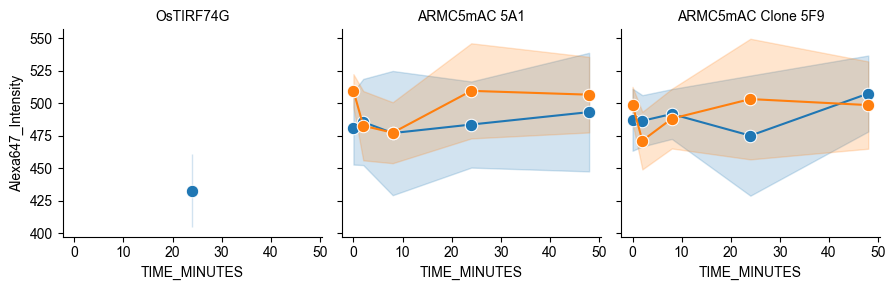

In [39]:
IntensitiesByWell_Experiment3_3E10 = IntensitiesByWell_Experiment3.query('PRIMARY == "pSer2 Pol II 3E10"')
IntensitiesByWell_Experiment3_3E10['TIME_MINUTES'] = IntensitiesByWell_Experiment3_3E10['DRUG TIME HOURS'].astype('int')


IntensitiesByWell_Experiment3_3E10['CELL_LABEL'] = IntensitiesByWell_Experiment3_3E10['CELL'].map(cell_relabel)

g = sns.FacetGrid(IntensitiesByWell_Experiment3_3E10,
                  col = 'CELL_LABEL',
                  col_order =  cell_relabel_order)

g.map_dataframe(sns.lineplot,
                x = 'TIME_MINUTES',
                y = 'Alexa647_Intensity',
                hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
                marker = 'o', markersize = 9,
                errorbar = 'sd')

g.set_titles(template="{col_name}")

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/2407901502.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment3_3E8['TIME_MINUTES'] = IntensitiesByWell_Experiment3_3E8['DRUG TIME HOURS'].astype('int')
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/2407901502.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment3_3E8['CELL_LABEL'] = IntensitiesByWell_Experiment3_3E8['CELL'].map(cell_relabel)


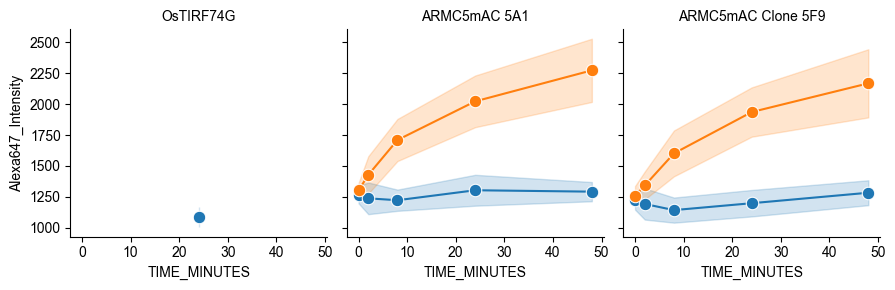

In [40]:
IntensitiesByWell_Experiment3_3E8 = IntensitiesByWell_Experiment3.query('PRIMARY == "pSer5 Pol II 3E8"')
IntensitiesByWell_Experiment3_3E8['TIME_MINUTES'] = IntensitiesByWell_Experiment3_3E8['DRUG TIME HOURS'].astype('int')


IntensitiesByWell_Experiment3_3E8['CELL_LABEL'] = IntensitiesByWell_Experiment3_3E8['CELL'].map(cell_relabel)

g = sns.FacetGrid(IntensitiesByWell_Experiment3_3E8,
                  col = 'CELL_LABEL',
                  col_order =  cell_relabel_order)

g.map_dataframe(sns.lineplot,
                x = 'TIME_MINUTES',
                y = 'Alexa647_Intensity',
                hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
                marker = 'o', markersize = 9,
                errorbar = 'sd')

g.set_titles(template="{col_name}")

### experiment 4

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/3150080002.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment4_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment4_Baseline['CELL'].map(cell_relabel)


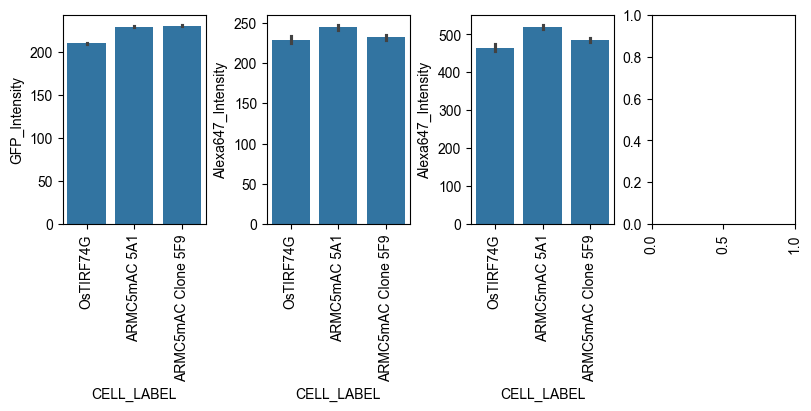

In [41]:
f, a = plt.subplots(ncols = 4, figsize = (8,4), layout = 'constrained')

IntensitiesByWell_Experiment4_Baseline = IntensitiesByWell_Experiment4.query('DRUG == "No addition" | DRUG == "Vehicle"')
IntensitiesByWell_Experiment4_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment4_Baseline['CELL'].map(cell_relabel)

sns.barplot(IntensitiesByWell_Experiment4_Baseline,
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'GFP_Intensity',
            ax = a[0])

sns.barplot(IntensitiesByWell_Experiment4_Baseline.query('PRIMARY == "pSer2 Pol II 3E10"'),
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'Alexa647_Intensity',
            ax = a[1])

sns.barplot(IntensitiesByWell_Experiment4_Baseline.query('PRIMARY == "pSer5 Pol II 3E8"'),
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'Alexa647_Intensity',
            ax = a[2])

for i in range(4):
    a[i].tick_params(axis = 'x', labelrotation = 90)

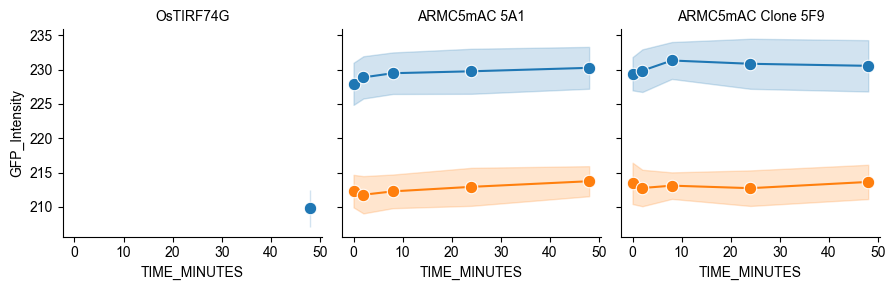

In [42]:
IntensitiesByWell_Experiment4_Exclude_No_Addition = IntensitiesByWell_Experiment4.query('DRUG != "No addition"')
IntensitiesByWell_Experiment4_Exclude_No_Addition['TIME_MINUTES'] = IntensitiesByWell_Experiment4_Exclude_No_Addition['DRUG TIME HOURS'].astype('int')

IntensitiesByWell_Experiment4_Exclude_No_Addition['CELL_LABEL'] = IntensitiesByWell_Experiment4_Exclude_No_Addition['CELL'].map(cell_relabel)

g = sns.FacetGrid(IntensitiesByWell_Experiment4_Exclude_No_Addition,
                  col='CELL_LABEL',
                  col_order=cell_relabel_order)

g.map_dataframe(sns.lineplot,
                x='TIME_MINUTES',
                y='GFP_Intensity',
                hue='DRUG', hue_order=['Vehicle', '10 µM 5PhIAA'],
                marker='o', markersize=9,
                errorbar='sd')

g.set_titles(template="{col_name}")

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/3224366771.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment4_3E10['TIME_MINUTES'] = IntensitiesByWell_Experiment4_3E10['DRUG TIME HOURS'].astype('int')
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/3224366771.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment4_3E10['CELL_LABEL'] = IntensitiesByWell_Experiment4_3E10['CELL'].map(cell_relabel)


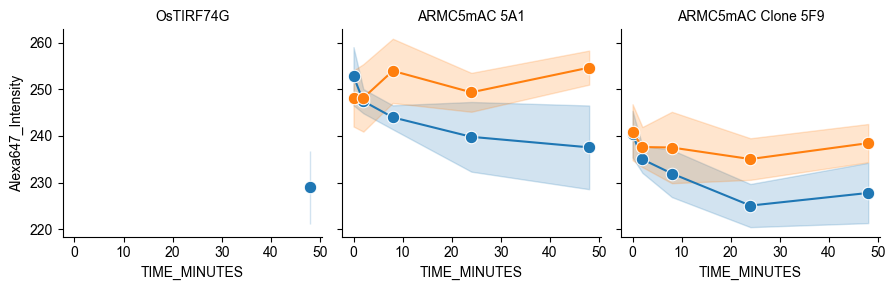

In [43]:
IntensitiesByWell_Experiment4_3E10 = IntensitiesByWell_Experiment4.query('PRIMARY == "pSer2 Pol II 3E10"')
IntensitiesByWell_Experiment4_3E10['TIME_MINUTES'] = IntensitiesByWell_Experiment4_3E10['DRUG TIME HOURS'].astype('int')

IntensitiesByWell_Experiment4_3E10['CELL_LABEL'] = IntensitiesByWell_Experiment4_3E10['CELL'].map(cell_relabel)

g = sns.FacetGrid(IntensitiesByWell_Experiment4_3E10,
                  col='CELL_LABEL',
                  col_order=cell_relabel_order)

g.map_dataframe(sns.lineplot,
                x='TIME_MINUTES',
                y='Alexa647_Intensity',
                hue='DRUG', hue_order=['Vehicle', '10 µM 5PhIAA'],
                marker='o', markersize=9,
                errorbar='sd')

g.set_titles(template="{col_name}")

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/3375838.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment4_3E8['TIME_MINUTES'] = IntensitiesByWell_Experiment4_3E8['DRUG TIME HOURS'].astype('int')
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/3375838.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment4_3E8['CELL_LABEL'] = IntensitiesByWell_Experiment4_3E8['CELL'].map(cell_relabel)


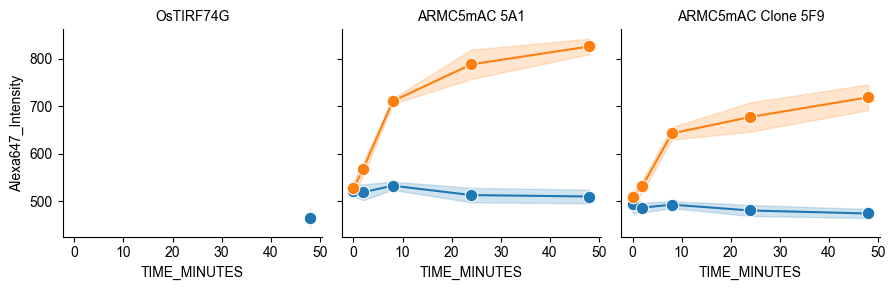

In [44]:
IntensitiesByWell_Experiment4_3E8 = IntensitiesByWell_Experiment4.query('PRIMARY == "pSer5 Pol II 3E8"')
IntensitiesByWell_Experiment4_3E8['TIME_MINUTES'] = IntensitiesByWell_Experiment4_3E8['DRUG TIME HOURS'].astype('int')

IntensitiesByWell_Experiment4_3E8['CELL_LABEL'] = IntensitiesByWell_Experiment4_3E8['CELL'].map(cell_relabel)

g = sns.FacetGrid(IntensitiesByWell_Experiment4_3E8,
                  col='CELL_LABEL',
                  col_order=cell_relabel_order)

g.map_dataframe(sns.lineplot,
                x='TIME_MINUTES',
                y='Alexa647_Intensity',
                hue='DRUG', hue_order=['Vehicle', '10 µM 5PhIAA'],
                marker='o', markersize=9,
                errorbar='sd')

g.set_titles(template="{col_name}")

### experiment 5

In [45]:
IntensitiesByWell_Experiment5.columns

Index(['WELL', 'Alexa647_Intensity', 'GFP_Intensity', 'DAPI_Intensity',
       'NucleusArea', 'CELL', 'DRUG', 'DRUG TIME HOURS', 'PRIMARY',
       'SECONDARY', 'TotalNumberCells', 'EXPERIMENT'],
      dtype='object')

In [46]:
IntensitiesByWell_Experiment5.PRIMARY.unique()

array(['Total Pol II F12', 'pSer2 Pol II 3E10'], dtype=object)

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/976524393.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment5_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment5_Baseline['CELL'].map(cell_relabel)


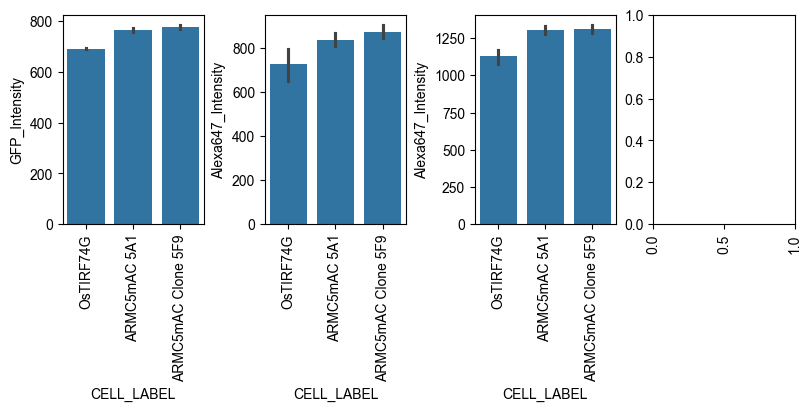

In [47]:
f, a = plt.subplots(ncols = 4, figsize = (8,4), layout = 'constrained')



IntensitiesByWell_Experiment5_Baseline = IntensitiesByWell_Experiment5.query('DRUG == "No addition" | DRUG == "Vehicle"')

IntensitiesByWell_Experiment5_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment5_Baseline['CELL'].map(cell_relabel)



sns.barplot(IntensitiesByWell_Experiment5_Baseline,
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'GFP_Intensity',
            ax = a[0])



sns.barplot(IntensitiesByWell_Experiment5_Baseline.query('PRIMARY == "Total Pol II F12"'),
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'Alexa647_Intensity',
            ax = a[1])



sns.barplot(IntensitiesByWell_Experiment5_Baseline.query('PRIMARY == "pSer2 Pol II 3E10"'),
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'Alexa647_Intensity',
            ax = a[2])



for i in range(4):

    a[i].tick_params(axis = 'x', labelrotation = 90)

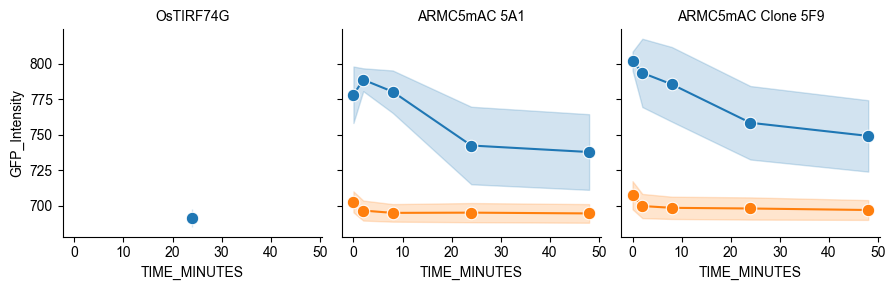

In [48]:
IntensitiesByWell_Experiment5_Exclude_No_Addition = IntensitiesByWell_Experiment5.query('DRUG != "No addition"')
IntensitiesByWell_Experiment5_Exclude_No_Addition['TIME_MINUTES'] = IntensitiesByWell_Experiment5_Exclude_No_Addition['DRUG TIME HOURS'].astype('int')

IntensitiesByWell_Experiment5_Exclude_No_Addition['CELL_LABEL'] = IntensitiesByWell_Experiment5_Exclude_No_Addition['CELL'].map(cell_relabel)

g = sns.FacetGrid(IntensitiesByWell_Experiment5_Exclude_No_Addition,
                  col='CELL_LABEL',
                  col_order=cell_relabel_order)

g.map_dataframe(sns.lineplot,
                x='TIME_MINUTES',
                y='GFP_Intensity',
                hue='DRUG', hue_order=['Vehicle', '10 µM 5PhIAA'],
                marker='o', markersize=9,
                errorbar='sd')

g.set_titles(template="{col_name}")

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/247096987.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment5_F12['TIME_MINUTES'] = IntensitiesByWell_Experiment5_F12['DRUG TIME HOURS'].astype('int')
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/247096987.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment5_F12['CELL_LABEL'] = IntensitiesByWell_Experiment5_F12['CELL'].map(cell_relabel)


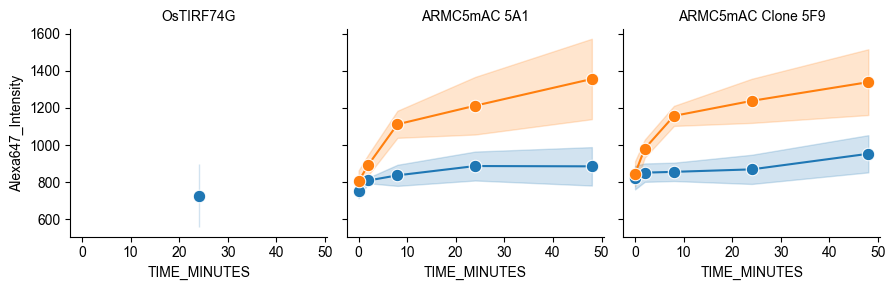

In [49]:
IntensitiesByWell_Experiment5_F12 = IntensitiesByWell_Experiment5.query('PRIMARY == "Total Pol II F12" & DRUG != "No addition"')
IntensitiesByWell_Experiment5_F12['TIME_MINUTES'] = IntensitiesByWell_Experiment5_F12['DRUG TIME HOURS'].astype('int')


IntensitiesByWell_Experiment5_F12['CELL_LABEL'] = IntensitiesByWell_Experiment5_F12['CELL'].map(cell_relabel)

g = sns.FacetGrid(IntensitiesByWell_Experiment5_F12,
                  col = 'CELL_LABEL',
                  col_order =  cell_relabel_order)

g.map_dataframe(sns.lineplot,
                x = 'TIME_MINUTES',
                y = 'Alexa647_Intensity',
                hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
                marker = 'o', markersize = 9,
                errorbar = 'sd')

g.set_titles(template="{col_name}")

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/1983077766.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment5_3E10['TIME_MINUTES'] = IntensitiesByWell_Experiment5_3E10['DRUG TIME HOURS'].astype('int')
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/1983077766.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment5_3E10['CELL_LABEL'] = IntensitiesByWell_Experiment5_3E10['CELL'].map(cell_relabel)


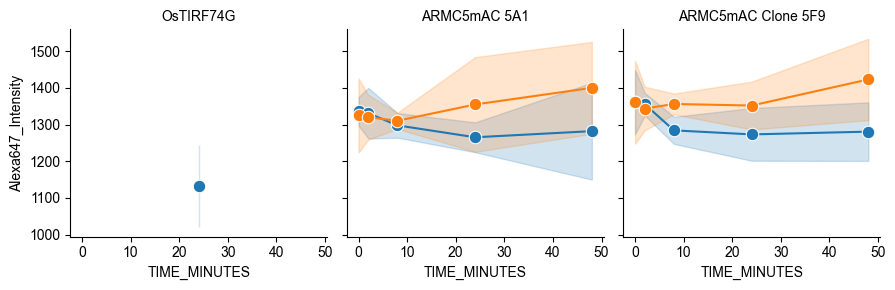

In [50]:
IntensitiesByWell_Experiment5_3E10 = IntensitiesByWell_Experiment5.query('PRIMARY == "pSer2 Pol II 3E10"')
IntensitiesByWell_Experiment5_3E10['TIME_MINUTES'] = IntensitiesByWell_Experiment5_3E10['DRUG TIME HOURS'].astype('int')

IntensitiesByWell_Experiment5_3E10['CELL_LABEL'] = IntensitiesByWell_Experiment5_3E10['CELL'].map(cell_relabel)

g = sns.FacetGrid(IntensitiesByWell_Experiment5_3E10,
                  col='CELL_LABEL',
                  col_order=cell_relabel_order)

g.map_dataframe(sns.lineplot,
                x='TIME_MINUTES',
                y='Alexa647_Intensity',
                hue='DRUG', hue_order=['Vehicle', '10 µM 5PhIAA'],
                marker='o', markersize=9,
                errorbar='sd')

g.set_titles(template="{col_name}")

### experiment 6

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/252323599.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment6_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment6_Baseline['CELL'].map(cell_relabel)


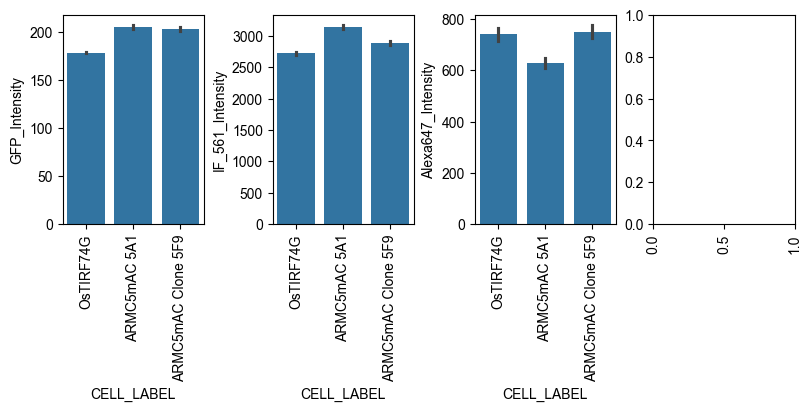

In [51]:
f, a = plt.subplots(ncols = 4, figsize = (8,4), layout = 'constrained')

IntensitiesByWell_Experiment6_Baseline = IntensitiesByWell_Experiment6.query('DRUG == "No addition" | DRUG == "Vehicle"')
IntensitiesByWell_Experiment6_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment6_Baseline['CELL'].map(cell_relabel)

sns.barplot(IntensitiesByWell_Experiment6_Baseline,
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'GFP_Intensity',
            ax = a[0])

sns.barplot(IntensitiesByWell_Experiment6_Baseline.query('PRIMARY == "pSer5 Pol II 3E8"'),
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'IF_561_Intensity',
            ax = a[1])

sns.barplot(IntensitiesByWell_Experiment6_Baseline.query('EU == "EU 1 mM, 30 mins"'),
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'Alexa647_Intensity',
            ax = a[2])


for i in range(4):
    a[i].tick_params(axis = 'x', labelrotation = 90)

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/2204906065.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment6_3E8['TIME_MINUTES'] = IntensitiesByWell_Experiment6_3E8['DRUG TIME HOURS'].astype('int')
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/2204906065.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment6_3E8['CELL_LABEL'] = IntensitiesByWell_Experiment6_3E8['CELL'].map(cell_relabel)


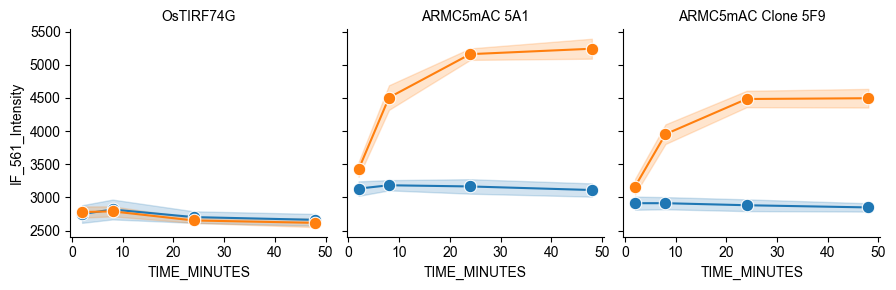

In [52]:
IntensitiesByWell_Experiment6_3E8 = IntensitiesByWell_Experiment6.query('PRIMARY == "pSer5 Pol II 3E8" & DRUG != "No addition"')
IntensitiesByWell_Experiment6_3E8['TIME_MINUTES'] = IntensitiesByWell_Experiment6_3E8['DRUG TIME HOURS'].astype('int')

IntensitiesByWell_Experiment6_3E8['CELL_LABEL'] = IntensitiesByWell_Experiment6_3E8['CELL'].map(cell_relabel)

g = sns.FacetGrid(IntensitiesByWell_Experiment6_3E8,
                  col='CELL_LABEL',
                  col_order=cell_relabel_order)

g.map_dataframe(sns.lineplot,
                x='TIME_MINUTES',
                y='IF_561_Intensity',
                hue='DRUG', hue_order=['Vehicle', '10 µM 5PhIAA'],
                marker='o', markersize=9,
                errorbar='sd')

g.set_titles(template="{col_name}")

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/3252312012.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment6_EU['TIME_MINUTES'] = IntensitiesByWell_Experiment6_EU['DRUG TIME HOURS'].astype('int')
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/3252312012.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment6_EU['CELL_LABEL'] = IntensitiesByWell_Experiment6_EU['CELL'].map(cell_relabel)


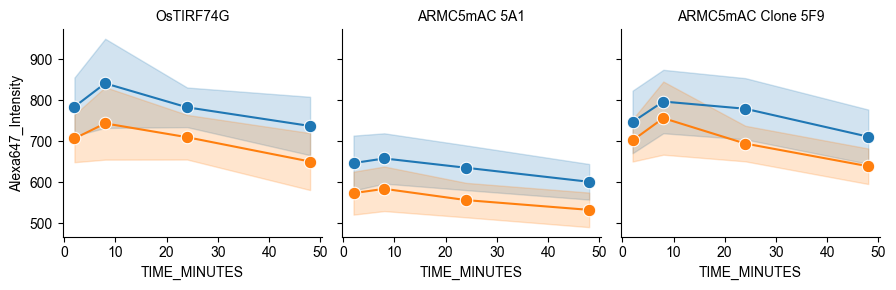

In [53]:
IntensitiesByWell_Experiment6_EU = IntensitiesByWell_Experiment6.query('EU == "EU 1 mM, 30 mins" & DRUG != "No addition"')
IntensitiesByWell_Experiment6_EU['TIME_MINUTES'] = IntensitiesByWell_Experiment6_EU['DRUG TIME HOURS'].astype('int')


IntensitiesByWell_Experiment6_EU['CELL_LABEL'] = IntensitiesByWell_Experiment6_EU['CELL'].map(cell_relabel)

g = sns.FacetGrid(IntensitiesByWell_Experiment6_EU,
                  col = 'CELL_LABEL',
                  col_order =  cell_relabel_order)

g.map_dataframe(sns.lineplot,
                x = 'TIME_MINUTES',
                y = 'Alexa647_Intensity',
                hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
                marker = 'o', markersize = 9,
                errorbar = 'sd')

g.set_titles(template="{col_name}")

## background subtract and normalise within experiments

### GFP

In [54]:
[x.CELL.unique() for x in [IntensitiesByWell_Experiment1, IntensitiesByWell_Experiment2, IntensitiesByWell_Experiment3, IntensitiesByWell_Experiment4, IntensitiesByWell_Experiment5]]

[array(['HCT116 OsTIRF74G', 'HCT116 OsTIRF74G ARMC5mAC Clone 5A1',
        'HCT116 OsTIRF74G ARMC5mAC Clone 5F9'], dtype=object),
 array(['HCT116 OsTIRF74G', 'HCT116 OsTIRF74G ARMC5mAC Clone 5A1',
        'HCT116 OsTIRF74G ARMC5mAC Clone 5F9'], dtype=object),
 array(['HCT116 OsTIRF74G', 'HCT116 OsTIRF74G ARMC5mAC Clone 5A1',
        'HCT116 OsTIRF74G ARMC5mAC Clone 5F9'], dtype=object),
 array(['HCT116 OsTIRF74G', 'HCT116 OsTIRF74G ARMC5mAC Clone 5F9',
        'HCT116 OsTIRF74G ARMC5mAC Clone 5A1'], dtype=object),
 array(['HCT116 OsTIRF74G', 'HCT116 OsTIRF74G ARMC5mAC Clone 5A1',
        'HCT116 OsTIRF74G ARMC5mAC Clone 5F9'], dtype=object)]

In [55]:
# Background subtraction using HCT116 OsTIRF74G cells

E1_GFP_Zero = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G"').GFP_Intensity.mean()
E2_GFP_Zero = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G"').GFP_Intensity.mean()
E3_GFP_Zero = IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G"').GFP_Intensity.mean()
E4_GFP_Zero = IntensitiesByWell_Experiment4.query('CELL == "HCT116 OsTIRF74G"').GFP_Intensity.mean()
E5_GFP_Zero = IntensitiesByWell_Experiment5.query('CELL == "HCT116 OsTIRF74G"').GFP_Intensity.mean()
E6_GFP_Zero = IntensitiesByWell_Experiment6.query('CELL == "HCT116 OsTIRF74G"').GFP_Intensity.mean()

IntensitiesByWell_Experiment1['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment1['GFP_Intensity'] - E1_GFP_Zero
IntensitiesByWell_Experiment2['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment2['GFP_Intensity'] - E2_GFP_Zero
IntensitiesByWell_Experiment3['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment3['GFP_Intensity'] - E3_GFP_Zero
IntensitiesByWell_Experiment4['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment4['GFP_Intensity'] - E4_GFP_Zero
IntensitiesByWell_Experiment5['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment5['GFP_Intensity'] - E5_GFP_Zero
IntensitiesByWell_Experiment6['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment6['GFP_Intensity'] - E6_GFP_Zero

# Normalization to Vehicle-treated HCT116 OsTIRF74G ARMC5mAC Clone 5A1

E1_GFP_NV = IntensitiesByWell_Experiment1.query(
    'CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "Vehicle"'
).GFP_Intensity_BGS.mean()

E2_GFP_NV = IntensitiesByWell_Experiment2.query(
    'CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "Vehicle"'
).GFP_Intensity_BGS.mean()

E3_GFP_NV = IntensitiesByWell_Experiment3.query(
    'CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "Vehicle"'
).GFP_Intensity_BGS.mean()

E4_GFP_NV = IntensitiesByWell_Experiment4.query(
    'CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "Vehicle"'
).GFP_Intensity_BGS.mean()

E5_GFP_NV = IntensitiesByWell_Experiment5.query(
    'CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "Vehicle"'
).GFP_Intensity_BGS.mean()

E6_GFP_NV = IntensitiesByWell_Experiment6.query(
    'CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "Vehicle"'
).GFP_Intensity_BGS.mean()

IntensitiesByWell_Experiment1['GFP_Intensity_FC'] = IntensitiesByWell_Experiment1['GFP_Intensity_BGS'] / E1_GFP_NV
IntensitiesByWell_Experiment2['GFP_Intensity_FC'] = IntensitiesByWell_Experiment2['GFP_Intensity_BGS'] / E2_GFP_NV
IntensitiesByWell_Experiment3['GFP_Intensity_FC'] = IntensitiesByWell_Experiment3['GFP_Intensity_BGS'] / E3_GFP_NV
IntensitiesByWell_Experiment4['GFP_Intensity_FC'] = IntensitiesByWell_Experiment4['GFP_Intensity_BGS'] / E4_GFP_NV
IntensitiesByWell_Experiment5['GFP_Intensity_FC'] = IntensitiesByWell_Experiment5['GFP_Intensity_BGS'] / E5_GFP_NV
IntensitiesByWell_Experiment6['GFP_Intensity_FC'] = IntensitiesByWell_Experiment6['GFP_Intensity_BGS'] / E6_GFP_NV

In [56]:
IntensitiesByWell = pd.concat([IntensitiesByWell_Experiment1, 
                               IntensitiesByWell_Experiment2, 
                               IntensitiesByWell_Experiment3,
                               IntensitiesByWell_Experiment4, 
                               IntensitiesByWell_Experiment5, 
                               IntensitiesByWell_Experiment6])
                               

In [57]:
IntensitiesByWell.DRUG.unique()

array(['No addition', 'Vehicle', '10 µM 5PhIAA'], dtype=object)

In [58]:
IntensitiesByWell['TIME_HOURS'] = IntensitiesByWell['DRUG TIME HOURS']

In [59]:
# fold untreated and vehicle wells into 0 timepoint

def time_in_auxin(d,t):
    if d == "10 µM 5PhIAA":
        return t
    elif d == "Vehicle":
        return 0
    elif d == "No addition":
        return 0

In [60]:
IntensitiesByWell['TIME_IN_AUXIN_HRS'] = IntensitiesByWell.apply(lambda x: time_in_auxin(x.DRUG,x.TIME_HOURS), axis = 1).astype(float)

In [61]:
[x['DRUG TIME HOURS'].unique() for x in [IntensitiesByWell_Experiment1, 
                               IntensitiesByWell_Experiment2, 
                               IntensitiesByWell_Experiment3,
                               IntensitiesByWell_Experiment4, 
                               IntensitiesByWell_Experiment5, 
                               IntensitiesByWell_Experiment6]]

[array(['No addition', '72', '48', '24', '8', '2'], dtype=object),
 array(['No addition', '2', '8', '24', '48', '72'], dtype=object),
 array([24. , 48. ,  8. ,  2. ,  0.5]),
 array([48. ,  0.5,  2. ,  8. , 24. ]),
 array([24. , 48. ,  8. ,  2. ,  0.5]),
 array(['No addition', '2', '8', '24', '48'], dtype=object)]

In [62]:
# filter for timepoints common to all experiments

IntensitiesByWell = IntensitiesByWell.query('TIME_IN_AUXIN_HRS in [0, 2, 8, 24, 48]')

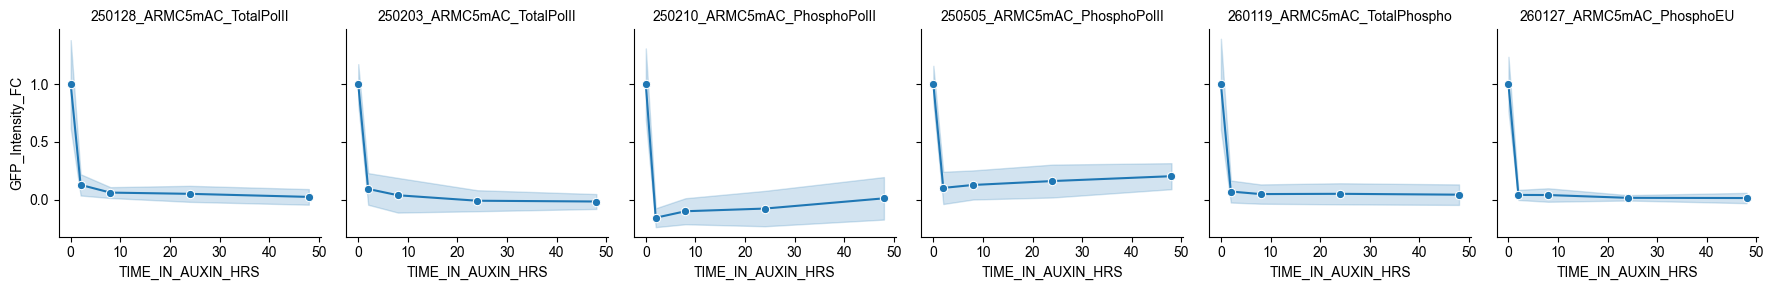

In [63]:
g = sns.FacetGrid(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1"'),
                  col = 'EXPERIMENT')

g.map_dataframe(sns.lineplot,
                x = 'TIME_IN_AUXIN_HRS',
                y = 'GFP_Intensity_FC',
                marker = 'o',
                errorbar = 'sd')

g.set_titles(template="{col_name}")

### Total Pol II (F12) Immunofluorescence

In [64]:
 IntensitiesByWell_Experiment2.columns

Index(['WELL', 'IF_561_Intensity', 'GFP_Intensity', 'DAPI_Intensity',
       'NucleusArea', 'CELL', 'EU', 'DRUG', 'DRUG TIME HOURS', 'PRIMARY',
       'SECONDARY', 'TotalNumberCells', 'Alexa647_Intensity', 'NucleusArea2',
       'EXPERIMENT', 'GFP_Intensity_BGS', 'GFP_Intensity_FC'],
      dtype='object')

In [65]:
E1_Mouse_Zero = IntensitiesByWell_Experiment1.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-mouse Alexa647"').IF_561_Intensity.mean()
E2_Mouse_Zero = IntensitiesByWell_Experiment2.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-mouse Alexa647"').IF_561_Intensity.mean()
E5_Mouse_Zero = IntensitiesByWell_Experiment5.query('WELL == "N12"').Alexa647_Intensity.mean()

Total_IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.query('PRIMARY == "Total Pol II F12"')
Total_IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.query('PRIMARY == "Total Pol II F12"')
Total_IntensitiesByWell_Experiment5 = IntensitiesByWell_Experiment5.query('PRIMARY == "Total Pol II F12"')

Total_IntensitiesByWell_Experiment1['IF_Intensity_BGS'] = Total_IntensitiesByWell_Experiment1['IF_561_Intensity'] - E1_Mouse_Zero
Total_IntensitiesByWell_Experiment2['IF_Intensity_BGS'] = Total_IntensitiesByWell_Experiment2['IF_561_Intensity'] - E2_Mouse_Zero
Total_IntensitiesByWell_Experiment5['IF_Intensity_BGS'] = Total_IntensitiesByWell_Experiment5['Alexa647_Intensity'] - E5_Mouse_Zero

E1_Total_NV = Total_IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "Vehicle"').IF_Intensity_BGS.mean()
E2_Total_NV = Total_IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "Vehicle"').IF_Intensity_BGS.mean()
E5_Total_NV = Total_IntensitiesByWell_Experiment5.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "Vehicle"').IF_Intensity_BGS.mean()

Total_IntensitiesByWell_Experiment1['IF_Intensity_FC'] = Total_IntensitiesByWell_Experiment1['IF_Intensity_BGS'] / E1_Total_NV
Total_IntensitiesByWell_Experiment2['IF_Intensity_FC'] = Total_IntensitiesByWell_Experiment2['IF_Intensity_BGS'] / E2_Total_NV
Total_IntensitiesByWell_Experiment5['IF_Intensity_FC'] = Total_IntensitiesByWell_Experiment5['IF_Intensity_BGS'] / E5_Total_NV

Total_IntensitiesByWell = pd.concat([Total_IntensitiesByWell_Experiment1, 
                               Total_IntensitiesByWell_Experiment2, 
                               Total_IntensitiesByWell_Experiment5])
                               

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/2528744753.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Total_IntensitiesByWell_Experiment1['IF_Intensity_BGS'] = Total_IntensitiesByWell_Experiment1['IF_561_Intensity'] - E1_Mouse_Zero
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/2528744753.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Total_IntensitiesByWell_Experiment2['IF_Intensity_BGS'] = Total_IntensitiesByWell_Experiment2['IF_561_Intensity'] - E2_Mouse_

In [66]:
Total_IntensitiesByWell['TIME_HOURS'] = Total_IntensitiesByWell['DRUG TIME HOURS']
Total_IntensitiesByWell['TIME_IN_AUXIN_HRS'] = Total_IntensitiesByWell.apply(lambda x: time_in_auxin(x.DRUG,x.TIME_HOURS), axis = 1).astype(float)

In [67]:
# filter for timepoints common to all experiments

Total_IntensitiesByWell = Total_IntensitiesByWell.query('TIME_IN_AUXIN_HRS in [0, 2, 8, 24, 48]')

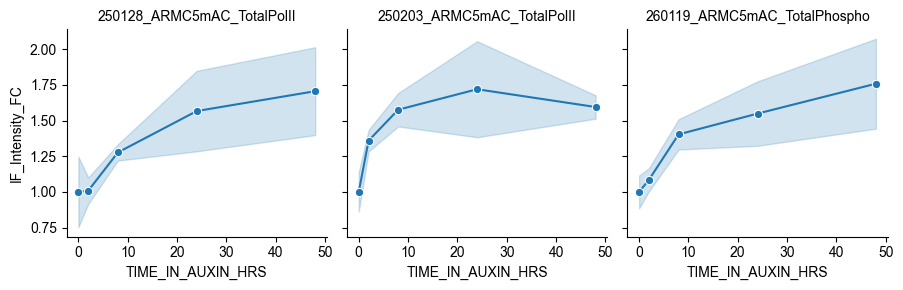

In [68]:
g = sns.FacetGrid(Total_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1"'),
                  col = 'EXPERIMENT')

g.map_dataframe(sns.lineplot,
                x = 'TIME_IN_AUXIN_HRS',
                y = 'IF_Intensity_FC',
                marker = 'o',
                errorbar = 'sd')

g.set_titles(template="{col_name}")

### pSer2 Pol II (3E10) Immunofluorescence

In [69]:
IntensitiesByWell_Experiment3.PRIMARY.unique(), IntensitiesByWell_Experiment4.PRIMARY.unique(), IntensitiesByWell_Experiment5.PRIMARY.unique()

(array(['pSer2 Pol II 3E10', 'pSer5 Pol II 3E8', 'No primary'],
       dtype=object),
 array(['pSer5 Pol II 3E8', 'pSer2 Pol II 3E10', 'No primary'],
       dtype=object),
 array(['Total Pol II F12', 'pSer2 Pol II 3E10'], dtype=object))

In [70]:
E3_Rat_Zero = IntensitiesByWell_Experiment3.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-rat Alexa647"').Alexa647_Intensity.mean()
E4_Rat_Zero = IntensitiesByWell_Experiment4.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-rat Alexa647"').Alexa647_Intensity.mean()
E5_Rat_Zero = IntensitiesByWell_Experiment5.query('WELL == "N12"').Alexa647_Intensity.mean()

pSer2_IntensitiesByWell_Experiment3 = IntensitiesByWell_Experiment3.query('PRIMARY == "pSer2 Pol II 3E10"')
pSer2_IntensitiesByWell_Experiment4 = IntensitiesByWell_Experiment4.query('PRIMARY == "pSer2 Pol II 3E10"')
pSer2_IntensitiesByWell_Experiment5 = IntensitiesByWell_Experiment5.query('PRIMARY == "pSer2 Pol II 3E10"')

pSer2_IntensitiesByWell_Experiment3['IF_Intensity_BGS'] = pSer2_IntensitiesByWell_Experiment3['Alexa647_Intensity'] - E3_Rat_Zero
pSer2_IntensitiesByWell_Experiment4['IF_Intensity_BGS'] = pSer2_IntensitiesByWell_Experiment4['Alexa647_Intensity'] - E4_Rat_Zero
pSer2_IntensitiesByWell_Experiment5['IF_Intensity_BGS'] = pSer2_IntensitiesByWell_Experiment5['Alexa647_Intensity'] - E5_Rat_Zero

E3_pSer2_NV = pSer2_IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "Vehicle"').IF_Intensity_BGS.mean()
E4_pSer2_NV = pSer2_IntensitiesByWell_Experiment4.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "Vehicle"').IF_Intensity_BGS.mean()
E5_pSer2_NV = pSer2_IntensitiesByWell_Experiment5.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "Vehicle"').IF_Intensity_BGS.mean()

pSer2_IntensitiesByWell_Experiment3['IF_Intensity_FC'] = pSer2_IntensitiesByWell_Experiment3['IF_Intensity_BGS'] / E3_pSer2_NV
pSer2_IntensitiesByWell_Experiment4['IF_Intensity_FC'] = pSer2_IntensitiesByWell_Experiment4['IF_Intensity_BGS'] / E4_pSer2_NV
pSer2_IntensitiesByWell_Experiment5['IF_Intensity_FC'] = pSer2_IntensitiesByWell_Experiment5['IF_Intensity_BGS'] / E5_pSer2_NV

pSer2_IntensitiesByWell = pd.concat([pSer2_IntensitiesByWell_Experiment3, pSer2_IntensitiesByWell_Experiment4, pSer2_IntensitiesByWell_Experiment5])

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/4075175491.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pSer2_IntensitiesByWell_Experiment3['IF_Intensity_BGS'] = pSer2_IntensitiesByWell_Experiment3['Alexa647_Intensity'] - E3_Rat_Zero
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/4075175491.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pSer2_IntensitiesByWell_Experiment4['IF_Intensity_BGS'] = pSer2_IntensitiesByWell_Experiment4['Alexa647_Intensity'] - E4_Rat_

In [71]:
pSer2_IntensitiesByWell['TIME_HOURS'] = pSer2_IntensitiesByWell['DRUG TIME HOURS']
pSer2_IntensitiesByWell['TIME_IN_AUXIN_HRS'] = pSer2_IntensitiesByWell.apply(lambda x: time_in_auxin(x.DRUG,x.TIME_HOURS), axis = 1).astype(float)

# filter for timepoints common to all experiments

pSer2_IntensitiesByWell = pSer2_IntensitiesByWell.query('TIME_IN_AUXIN_HRS in [0, 2, 8, 24, 48]')

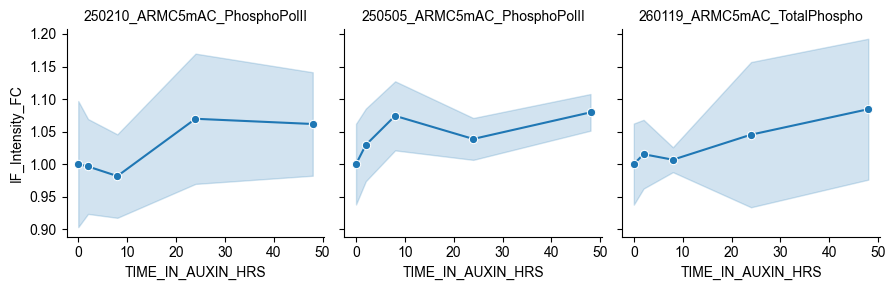

In [72]:
g = sns.FacetGrid(pSer2_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1"'),
                  col = 'EXPERIMENT')

g.map_dataframe(sns.lineplot,
                x = 'TIME_IN_AUXIN_HRS',
                y = 'IF_Intensity_FC',
                marker = 'o',
                errorbar = 'sd')

g.set_titles(template="{col_name}")

### EU incorporation

In [73]:
IntensitiesByWell_Experiment1.EU.unique(), IntensitiesByWell_Experiment2.EU.unique(), IntensitiesByWell_Experiment6.EU.unique()

(array(['No addition', 'EU 1 mM, 30 mins'], dtype=object),
 array(['No addition', 'EU 1 mM, 30 mins'], dtype=object),
 array(['No addition', 'EU 1 mM, 30 mins'], dtype=object))

In [74]:
E1_EU_Zero = IntensitiesByWell_Experiment1.query('EU == "No addition"').Alexa647_Intensity.mean()
E2_EU_Zero = IntensitiesByWell_Experiment2.query('EU == "No addition"').Alexa647_Intensity.mean()
E6_EU_Zero = IntensitiesByWell_Experiment6.query('EU == "No addition"').Alexa647_Intensity.mean()

EU_IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.query('EU == "EU 1 mM, 30 mins"')
EU_IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.query('EU == "EU 1 mM, 30 mins"')
EU_IntensitiesByWell_Experiment6 = IntensitiesByWell_Experiment6.query('EU == "EU 1 mM, 30 mins"')


EU_IntensitiesByWell_Experiment1['EU_Intensity_BGS'] = EU_IntensitiesByWell_Experiment1['Alexa647_Intensity'] - E1_EU_Zero
EU_IntensitiesByWell_Experiment2['EU_Intensity_BGS'] = EU_IntensitiesByWell_Experiment2['Alexa647_Intensity'] - E1_EU_Zero
EU_IntensitiesByWell_Experiment6['EU_Intensity_BGS'] = EU_IntensitiesByWell_Experiment6['Alexa647_Intensity'] - E1_EU_Zero

E1_EU_NV = EU_IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "Vehicle"').EU_Intensity_BGS.mean()
E2_EU_NV = EU_IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "Vehicle"').EU_Intensity_BGS.mean()
E6_EU_NV = EU_IntensitiesByWell_Experiment6.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "Vehicle"').EU_Intensity_BGS.mean()

EU_IntensitiesByWell_Experiment1['EU_Intensity_FC'] = EU_IntensitiesByWell_Experiment1['EU_Intensity_BGS'] / E1_EU_NV
EU_IntensitiesByWell_Experiment2['EU_Intensity_FC'] = EU_IntensitiesByWell_Experiment2['EU_Intensity_BGS'] / E2_EU_NV
EU_IntensitiesByWell_Experiment6['EU_Intensity_FC'] = EU_IntensitiesByWell_Experiment6['EU_Intensity_BGS'] / E6_EU_NV

EU_IntensitiesByWell = pd.concat([EU_IntensitiesByWell_Experiment1, EU_IntensitiesByWell_Experiment2, EU_IntensitiesByWell_Experiment6])

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/119055208.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EU_IntensitiesByWell_Experiment1['EU_Intensity_BGS'] = EU_IntensitiesByWell_Experiment1['Alexa647_Intensity'] - E1_EU_Zero
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_27443/119055208.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EU_IntensitiesByWell_Experiment2['EU_Intensity_BGS'] = EU_IntensitiesByWell_Experiment2['Alexa647_Intensity'] - E1_EU_Zero
/var/folde

In [75]:
EU_IntensitiesByWell['TIME_HOURS'] = EU_IntensitiesByWell['DRUG TIME HOURS']
EU_IntensitiesByWell['TIME_IN_AUXIN_HRS'] = EU_IntensitiesByWell.apply(lambda x: time_in_auxin(x.DRUG,x.TIME_HOURS), axis = 1).astype(float)

# filter for timepoints common to all experiments
EU_IntensitiesByWell = EU_IntensitiesByWell.query('TIME_IN_AUXIN_HRS in [0, 2, 8, 24, 48]')

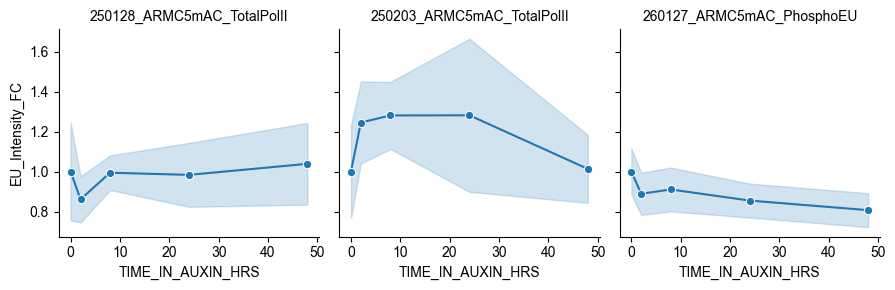

In [76]:
g = sns.FacetGrid(EU_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1"'),
                  col = 'EXPERIMENT')

g.map_dataframe(sns.lineplot,
                x = 'TIME_IN_AUXIN_HRS',
                y = 'EU_Intensity_FC',
                marker = 'o',
                errorbar = 'sd')

g.set_titles(template="{col_name}")

## Plots for manuscript

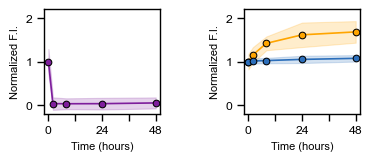

In [77]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (4, 1.5), layout = 'constrained')


sns.lineplot(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1"'), 
             x = 'TIME_IN_AUXIN_HRS', 
             y = 'GFP_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[0], 
             color = 'xkcd:purple', 
             legend = False)

sns.lineplot(Total_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1"'), 
             x = 'TIME_IN_AUXIN_HRS', 
             y = 'IF_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[1], 
             color = 'orange', 
             legend = False)

sns.lineplot(pSer2_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1"'), 
             x = 'TIME_IN_AUXIN_HRS', 
             y = 'IF_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[1], 
             color = 'xkcd:medium blue', 
             legend = False)

for i in range(2):
    a[i].set_xlabel('Time (hours)', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.9)
    a[i].set_ylim(-0.2,2.2)
    a[i].set_yticks([0,1,2])
    a[i].set_xticks([0, 12, 24, 36, 48], labels=['0', '', '24', '', '48'], minor=False)
    a[i].set_xlim(-2,50)


plt.savefig('ARMC5mAC_GFP_Total_pSer2.svg')

### save normalized data to csv

In [101]:
ARMC5_mAC_well_summary_gfp_normalised = IntensitiesByWell[['EXPERIMENT', 'WELL','CELL', 'DRUG', 'DRUG TIME HOURS', 'TIME_IN_AUXIN_HRS', 'PRIMARY', 'SECONDARY', 'TotalNumberCells','GFP_Intensity','GFP_Intensity_BGS','GFP_Intensity_FC']]
ARMC5_mAC_well_summary_gfp_normalised.to_csv('ARMC5_mAC_well_summary_gfp_normalised.csv')

In [97]:
ARMC5_mAC_well_summary_if_totalpolii_normalised = Total_IntensitiesByWell[['EXPERIMENT', 'WELL','CELL', 'EU', 'DRUG', 'DRUG TIME HOURS', 'TIME_HOURS', 'TIME_IN_AUXIN_HRS', 'PRIMARY', 'SECONDARY', 'TotalNumberCells','IF_Intensity_BGS', 'IF_Intensity_FC']]
ARMC5_mAC_well_summary_if_totalpolii_normalised.to_csv('ARMC5_mAC_well_summary_if_totalpolii_normalised.csv')

In [105]:
ARMC5_mAC_well_summary_if_pser2polii_normalised = pSer2_IntensitiesByWell[['EXPERIMENT', 'WELL','CELL', 'DRUG', 'DRUG TIME HOURS', 'TIME_HOURS', 'TIME_IN_AUXIN_HRS', 'PRIMARY', 'SECONDARY', 'TotalNumberCells','IF_Intensity_BGS', 'IF_Intensity_FC']]
ARMC5_mAC_well_summary_if_pser2polii_normalised.to_csv('ARMC5_mAC_well_summary_if_pser2polii_normalised.csv')

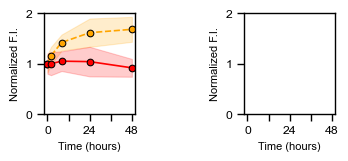

In [81]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (4, 1.5), layout = 'constrained')

sns.lineplot(Total_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1"'), 
             x = 'TIME_IN_AUXIN_HRS', 
             y = 'IF_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[0], 
             color = 'orange', 
             linestyle = '--',
             legend = False)

sns.lineplot(EU_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1"').reset_index(), 
             x = 'TIME_IN_AUXIN_HRS', 
             y = 'EU_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[0], 
             color = 'red', 
             legend = False)

for i in range(2):
    a[i].set_xlabel('Time (hours)', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(1.1)
    a[i].set_ylim(0,2)
    a[i].set_yticks([0,1,2])
    a[i].set_xticks([0, 12, 24, 36, 48], labels=['0', '', '24', '', '48'], minor=False)
    a[i].set_xlim(-2,50)

plt.savefig('ARMC5mAC_Total_EU.svg')

In [106]:
EU_IntensitiesByWell.columns.to_list()

['WELL',
 'IF_561_Intensity',
 'GFP_Intensity',
 'DAPI_Intensity',
 'NucleusArea',
 'CELL',
 'EU',
 'DRUG',
 'DRUG TIME HOURS',
 'PRIMARY',
 'SECONDARY',
 'TotalNumberCells',
 'Alexa647_Intensity',
 'NucleusArea2',
 'EXPERIMENT',
 'GFP_Intensity_BGS',
 'GFP_Intensity_FC',
 'EU_Intensity_BGS',
 'EU_Intensity_FC',
 'DAPI_Intensity_x',
 'DAPI_Intensity_y',
 'TIME_HOURS',
 'TIME_IN_AUXIN_HRS']

In [107]:
ARMC5_mAC_well_summary_eu_normalised = EU_IntensitiesByWell[['EXPERIMENT', 'WELL','CELL', 'EU', 'DRUG', 'DRUG TIME HOURS', 'TIME_HOURS', 'TIME_IN_AUXIN_HRS', 'PRIMARY', 'SECONDARY', 'TotalNumberCells','EU_Intensity_BGS', 'EU_Intensity_FC']]
ARMC5_mAC_well_summary_eu_normalised.to_csv('ARMC5_mAC_well_summary_eu_normalised.csv')

In [82]:
EU_IntensitiesByWell[['WELL','TIME_IN_AUXIN_HRS','CELL']].groupby(['TIME_IN_AUXIN_HRS','CELL']).count().reset_index()

,TIME_IN_AUXIN_HRS,CELL,WELL
0,0.0,HCT116 OsTIRF74G,150
1,0.0,HCT116 OsTIRF74G ARMC5mAC Clone 5A1,90
2,0.0,HCT116 OsTIRF74G ARMC5mAC Clone 5F9,90
3,2.0,HCT116 OsTIRF74G,18
4,2.0,HCT116 OsTIRF74G ARMC5mAC Clone 5A1,18
5,2.0,HCT116 OsTIRF74G ARMC5mAC Clone 5F9,18
6,8.0,HCT116 OsTIRF74G,18
7,8.0,HCT116 OsTIRF74G ARMC5mAC Clone 5A1,18
8,8.0,HCT116 OsTIRF74G ARMC5mAC Clone 5F9,18
9,24.0,HCT116 OsTIRF74G,18


## Total Pol II versus pSer2 Pol II plot

In [83]:
# pull means and standard deviation values for both total Pol II IF and pSer2 IF, vehicle treated

TotalVehicleMean = Total_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "Vehicle"')['IF_Intensity_FC'].mean()
TotalVehicleSD = Total_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "Vehicle"')['IF_Intensity_FC'].std()

pSer2VehicleMean = pSer2_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "Vehicle"')['IF_Intensity_FC'].mean()
pSer2VehicleSD = pSer2_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "Vehicle"')['IF_Intensity_FC'].std()


# pull means and standard deviation values for both total Pol II IF and pSer2 IF, grouped by timepoint

TotalGroupedMean = Total_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "10 µM 5PhIAA"')[['TIME_IN_AUXIN_HRS','IF_Intensity_FC']].groupby(['TIME_IN_AUXIN_HRS']).mean().reset_index()
TotalGroupedSD = Total_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "10 µM 5PhIAA"')[['TIME_IN_AUXIN_HRS','IF_Intensity_FC']].groupby(['TIME_IN_AUXIN_HRS']).std().reset_index()

pSer2GroupedMean = pSer2_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "10 µM 5PhIAA"')[['TIME_IN_AUXIN_HRS','IF_Intensity_FC']].groupby(['TIME_IN_AUXIN_HRS']).mean().reset_index()
pSer2GroupedSD = pSer2_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "10 µM 5PhIAA"')[['TIME_IN_AUXIN_HRS','IF_Intensity_FC']].groupby(['TIME_IN_AUXIN_HRS']).std().reset_index()

TotalGroupedMean.rename(columns = {'IF_Intensity_FC' : 'TotalPolII'}, inplace = True)
TotalGroupedSD.rename(columns = {'IF_Intensity_FC' : 'TotalPolII_SD'}, inplace = True)
pSer2GroupedMean.rename(columns = {'IF_Intensity_FC' : 'pSer2PolII'}, inplace = True)
pSer2GroupedSD.rename(columns = {'IF_Intensity_FC' : 'pSer2PolII_SD'}, inplace = True)

XYPLOT = TotalGroupedMean.merge(TotalGroupedSD).merge(pSer2GroupedMean).merge(pSer2GroupedSD)

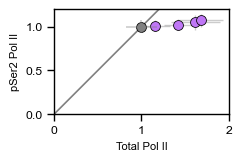

In [84]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (5,1.5), layout = 'constrained')

# plot error bars for vehicle treated point

plt.errorbar(x = [TotalVehicleMean], 
             xerr = [TotalVehicleSD],
             y = [pSer2VehicleMean], 
             yerr = [pSer2VehicleSD],
             color = 'grey',
             alpha = 0.4)

# plot error bars for 5-ph-iaa treated points

plt.errorbar(x = XYPLOT.TotalPolII,
             xerr = XYPLOT.TotalPolII_SD,
             y = XYPLOT.pSer2PolII,
             yerr = XYPLOT.pSer2PolII_SD,
             linestyle = "None", linewidth = 1,
             color = 'grey', 
             alpha = 0.4, zorder = 1)

# plot vehicle treated point in grey

sns.scatterplot(x = [TotalVehicleMean], y = [pSer2VehicleMean], color = 'grey', s = 50, edgecolor = 'black')

# plot total and pSer2 at each time and concentration

h = sns.scatterplot(XYPLOT,
                x = 'TotalPolII',
                y = 'pSer2PolII',

                color = 'xkcd:light purple',
                marker = 'o', s = 50, edgecolor = 'black')

a.set_box_aspect(0.6)
a.set_ylim(0,1.2)
a.set_xlim(0,2)
a.set_xticks([0,1.0,2.0])
a.set_yticks([0,0.5,1,])

a.axline(xy1 = (0,0), slope = 1, color = 'grey', zorder = 0)

a.set_xlabel('Total Pol II', fontsize = 8)

a.set_ylabel('pSer2 Pol II', fontsize = 8)

plt.savefig('total_polii_vs_pser2_polii_ARMC5mAC.svg')

## Total Pol II versus EU incorporation plot

In [85]:
EUVehicleMean = EU_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "Vehicle"')['EU_Intensity_FC'].mean()
EUVehicleSD = EU_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "Vehicle"')['EU_Intensity_FC'].std()

EUGroupedMean = EU_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "10 µM 5PhIAA"')[['TIME_IN_AUXIN_HRS','EU_Intensity_FC']].groupby(['TIME_IN_AUXIN_HRS']).mean().reset_index()
EUGroupedSD = EU_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "10 µM 5PhIAA"')[['TIME_IN_AUXIN_HRS','EU_Intensity_FC']].groupby(['TIME_IN_AUXIN_HRS']).std().reset_index()

EUGroupedMean.rename(columns = {'EU_Intensity_FC' : 'EU'}, inplace = True)
EUGroupedSD.rename(columns = {'EU_Intensity_FC' : 'EU_SD'}, inplace = True)

XYPLOT_EU = TotalGroupedMean.merge(TotalGroupedSD).merge(EUGroupedMean).merge(EUGroupedSD)

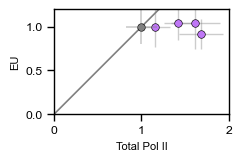

In [86]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (5,1.5), layout = 'constrained')

# plot error bars for vehicle treated point

plt.errorbar(x = [TotalVehicleMean], 
             xerr = [TotalVehicleSD],
             y = [EUVehicleMean], 
             yerr = [EUVehicleSD],
             color = 'grey',
             alpha = 0.4)

# plot error bars for 5-ph-iaa treated points

plt.errorbar(x = XYPLOT_EU.TotalPolII,
             xerr = XYPLOT_EU.TotalPolII_SD,
             y = XYPLOT_EU.EU,
             yerr = XYPLOT_EU.EU_SD,
             linestyle = "None", linewidth = 1,
             color = 'grey', 
             alpha = 0.4, zorder = 1)

# plot vehicle treated point in grey

sns.scatterplot(x = [TotalVehicleMean], y = [EUVehicleMean], color = 'grey', s = 30, edgecolor = 'black')

# plot total and pSer2 at each time and concentration

h = sns.scatterplot(XYPLOT_EU,
                x = 'TotalPolII',
                y = 'EU',

                color = 'xkcd:light purple',
                marker = 'o', s = 30, edgecolor = 'black')

a.set_box_aspect(0.6)
a.set_ylim(0,1.2)
a.set_xlim(0,2)
a.set_xticks([0,1.0,2.0])
a.set_yticks([0,0.5,1,])

a.axline(xy1 = (0,0), slope = 1, color = 'grey', zorder = 0)

a.set_xlabel('Total Pol II', fontsize = 8)

a.set_ylabel('EU', fontsize = 8)

plt.savefig('total_polii_vs_EU_ARMC5mAC.svg')

In [87]:
XYPLOT_EU

,TIME_IN_AUXIN_HRS,TotalPolII,TotalPolII_SD,EU,EU_SD
0,2.0,1.154879,0.177075,0.998410,0.227909
1,8.0,1.419283,0.158281,1.048878,0.195521
2,24.0,1.615145,0.281508,1.039902,0.294161
3,48.0,1.681950,0.247720,0.916462,0.177220


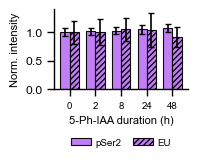

In [88]:

cell = "HCT116 OsTIRF74G ARMC5mAC Clone 5A1"

def build_assay_summary(df, assay_name, intensity_col):
    # Vehicle
    vehicle = df.query('CELL == @cell & DRUG == "Vehicle"')[intensity_col]
    rows = [{
        "Condition": "0",
        "Assay": assay_name,
        "Mean": vehicle.mean(),
        "SD": vehicle.std()
    }]

    # 5PhIAA time course
    grouped = (
        df.query('CELL == @cell & DRUG == "10 µM 5PhIAA"')[["TIME_IN_AUXIN_HRS", intensity_col]]
          .groupby("TIME_IN_AUXIN_HRS")
          .agg(Mean=(intensity_col, "mean"), SD=(intensity_col, "std"))
          .reset_index()
    )

    for _, r in grouped.iterrows():
        rows.append({
            "Condition": f'{r["TIME_IN_AUXIN_HRS"]:g}',
            "Assay": assay_name,
            "Mean": r["Mean"],
            "SD": r["SD"]
        })

    return pd.DataFrame(rows)

# Build summaries
pser2_summary = build_assay_summary(pSer2_IntensitiesByWell, "pSer2", "IF_Intensity_FC")
eu_summary    = build_assay_summary(EU_IntensitiesByWell,    "EU",    "EU_Intensity_FC")

plot_df = pd.concat([pser2_summary, eu_summary], ignore_index=True)

# Condition order: Vehicle first, then timepoints in numeric order
condition_order = ["0"] + sorted(
    [c for c in plot_df["Condition"].unique() if c != "0"],
    key=lambda s: float(s.split()[0])
)

plot_df["Condition"] = pd.Categorical(plot_df["Condition"], categories=condition_order, ordered=True)

sns.set_context("paper")

f, a = plt.subplots(figsize=(3.5, 1.5), layout="constrained")

x = np.arange(len(condition_order))
width = 0.36

assay_styles = {
    "pSer2": {"color": "xkcd:light purple", "hatch": ""},
    "EU":    {"color": "xkcd:light purple", "hatch": "//////"},   # denser hatch
}

for i, assay in enumerate(["pSer2", "EU"]):
    sub = (
        plot_df.loc[plot_df["Assay"] == assay]
        .set_index("Condition")
        .reindex(condition_order)
    )

    xpos = x + (i - 0.5) * width

    a.bar(
        xpos,
        sub["Mean"],
        width=width,
        yerr=sub["SD"],
        capsize=2,
        color=assay_styles[assay]["color"],
        edgecolor="black",
        linewidth=0.8,
        hatch=assay_styles[assay]["hatch"],
        alpha=0.95,
        label=assay,
    )

a.set_xticks(x)
a.set_xticklabels(condition_order, fontsize=7)

a.set_ylabel("Norm. intensity", fontsize=8)
a.set_xlabel("5-Ph-IAA duration (h)", fontsize=8)

a.set_box_aspect(0.6)

# Legend outside the plotting area on the right
a.legend(
    frameon=False,
    fontsize=7,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.5),
    ncol=2,
    columnspacing=1.2,
    handletextpad=0.5
)

sns.despine(ax=a)

plt.savefig(
    "pser2_vs_EU_barplot_ARMC5mAC.svg",
    bbox_inches="tight"
)
plt.savefig(
    "pser2_vs_EU_barplot_ARMC5mAC.pdf",
    bbox_inches="tight"
)